## Part 1: Exploratory Data Analysis (EDA)

In [70]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings("ignore")

In [71]:
# find the root from the project directory
def find_project_root(path):
    """Find the root directory of a Git repository."""
    path = Path(path).resolve()
    while True:
        if (path / '.git').exists():
            return path
        if path.parent == path:
            break
        path = path.parent
    return None

In [72]:
# use pathlib for better path management
# Find the root directory of the project
CURR_DIR = Path().resolve()
ROOT_DIR = find_project_root(CURR_DIR)

# Define the data directory
DATA_DIR = ROOT_DIR / 'data'


In [73]:
# Load the customer data
customer_data = pd.read_csv(DATA_DIR / 'raw_data' / 'mall_customers.csv')

# Create a copy of the data
df = customer_data.copy(deep=True)
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [74]:
# normalize column names for convenience
df = df.rename(columns={
    'CustomerID': 'CustomerID',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
})

In [75]:
df = df.drop(columns = ['CustomerID'])
df['annual_income'] = df['annual_income'] * 1000
df

,gender,age,annual_income,spending_score
0,Male,19,15000,39
1,Male,21,15000,81
2,Female,20,16000,6
3,Female,23,16000,77
4,Female,31,17000,40
...,...,...,...,...
195,Female,35,120000,79
196,Female,45,126000,28
197,Male,32,126000,74
198,Male,32,137000,18


#### save data version

In [76]:
df.to_csv(DATA_DIR / 'data_versions' / 'customer_data_version_01.csv', index=False)

In [77]:
# selecting numerical features and categorical features

numerical_features = [col for col in df.select_dtypes(include="number").columns if col != "CustomerID"]
categorical_features = df.select_dtypes(include="object").columns.tolist()

print(f"numerical features: {numerical_features}")
print(f"categorical features: {categorical_features}")

numerical features: ['age', 'annual_income', 'spending_score']
categorical features: ['gender']


### 1.1 Univariate Analysis

#### Numerical Features

In [78]:
# summary statistics

print(df[numerical_features].info())
print(df[numerical_features].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             200 non-null    int64
 1   annual_income   200 non-null    int64
 2   spending_score  200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB
None
              age  annual_income  spending_score
count  200.000000     200.000000      200.000000
mean    38.850000   60560.000000       50.200000
std     13.969007   26264.721165       25.823522
min     18.000000   15000.000000        1.000000
25%     28.750000   41500.000000       34.750000
50%     36.000000   61500.000000       50.000000
75%     49.000000   78000.000000       73.000000
max     70.000000  137000.000000       99.000000


In [79]:
def get_shape_measures(data: pd.DataFrame, feature_list: list[str]) -> dict:
    """Return skewness and kurtosis value of numerical feature
        data: data_frame
        feature_list: numerical feature names
        return : dictionary of skewness and kurtosis value of features and their descriptions
    """
    measure_of_shape = {}
    for feature in feature_list:
        shape = {}
        skew = data[feature].skew()
        kurt = data[feature].kurtosis()

        shape["skew"] = skew
        if skew < -1:
            shape["skew_description"] = "Highly left-skewed"
        elif skew < -0.5:
            shape["skew_description"] = "Moderately left-skewed"
        elif skew < 0:
            shape["skew_description"] = "Slightly left-skewed"
        elif skew == 0:
            shape["skew_description"] = "Symmetric"
        elif skew < 0.5:
            shape["skew_description"] = "Slightly right-skewed"
        elif skew < 1:
            shape["skew_description"] = "Moderately right-skewed"
        else:
            shape["skew_description"] = "Highly right-skewed"

        shape["kurt"] = kurt
        if kurt < 2:
            shape["kurt_description"] = "Very platykurtic(flat)"
        elif kurt < 3:
            shape["kurt_description"] = "Platykurtic(less peaked)"
        elif kurt == 3:
            shape["kurt_description"] = "Mesokurtic(normal)"
        elif kurt < 4:
            shape["kurt_description"] = "Leptokurtic(more peaked)"
        else:
            shape["kurt_description"] = "Very leptokurtic(very peaked)"
        
        measure_of_shape[feature] = shape
    return measure_of_shape

In [80]:
measure_shape = get_shape_measures(df, numerical_features)
pd.DataFrame(measure_shape)

,age,annual_income,spending_score
skew,0.485569,0.321843,-0.04722
skew_description,Slightly right-skewed,Slightly right-skewed,Slightly left-skewed
kurt,-0.671573,-0.098487,-0.826629
kurt_description,Very platykurtic(flat),Very platykurtic(flat),Very platykurtic(flat)


In [81]:
def univariate_numerical_plots(data: pd.DataFrame, feature: str) -> plt.subplot:
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
    
    # Histogram
    sns.histplot(data=data, x=feature, ax=axes[0, 0], kde=True)
    axes[0, 0].set_title(f"Histogram of {feature}")
    
    # Density Plot
    sns.kdeplot(data=data, x=feature, ax=axes[0, 1], fill=True)
    axes[0, 1].set_title(f"Density Plot of {feature}")
    
    # Boxplot
    sns.boxplot(data=data, x=feature, ax=axes[1, 0])
    axes[1, 0].set_title(f"Boxplot of {feature}")
    
    # QQ Plot
    # Note: Seaborn does not have a built-in QQ plot function.
    # We will use scipy.stats.probplot instead.
    from scipy import stats
    stats.probplot(data[feature], dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f"QQ Plot of {feature}")
    plt.suptitle(f"Univariate plot: {feature}")
    
    plt.tight_layout()
    plt.show()

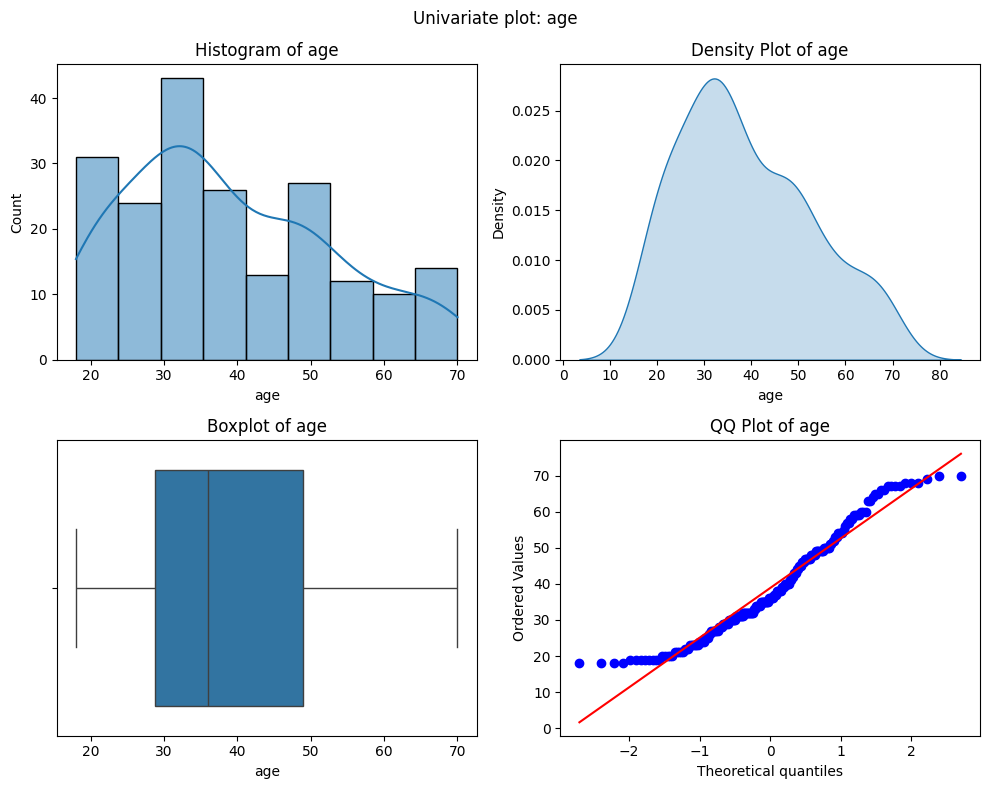

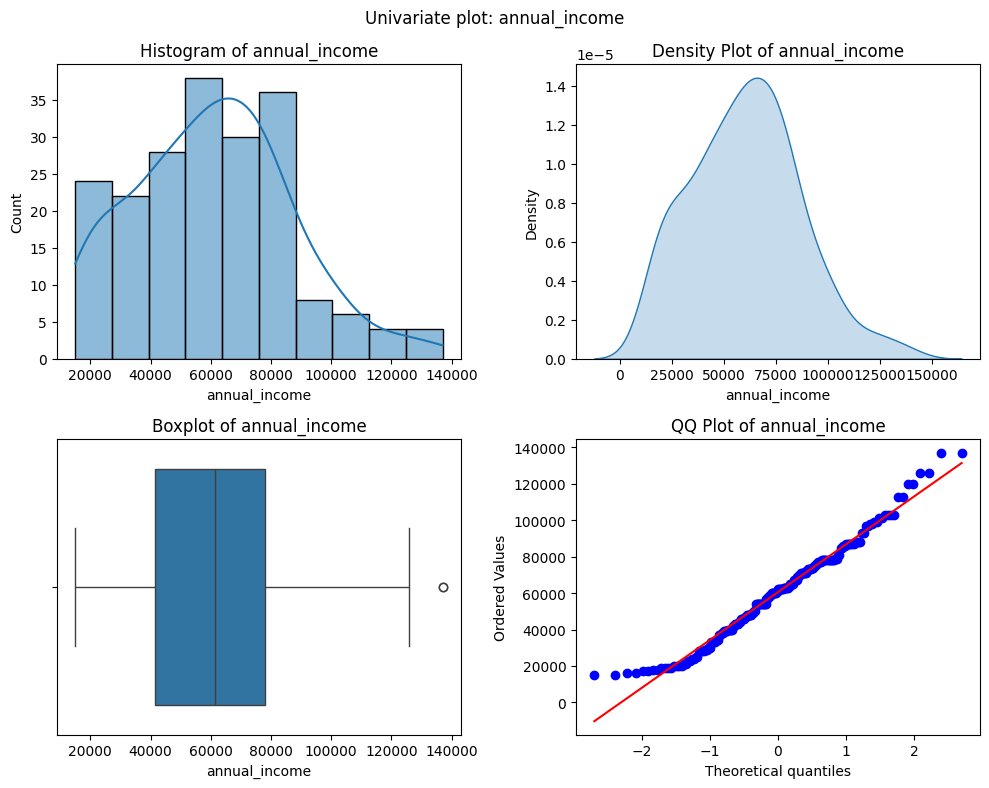

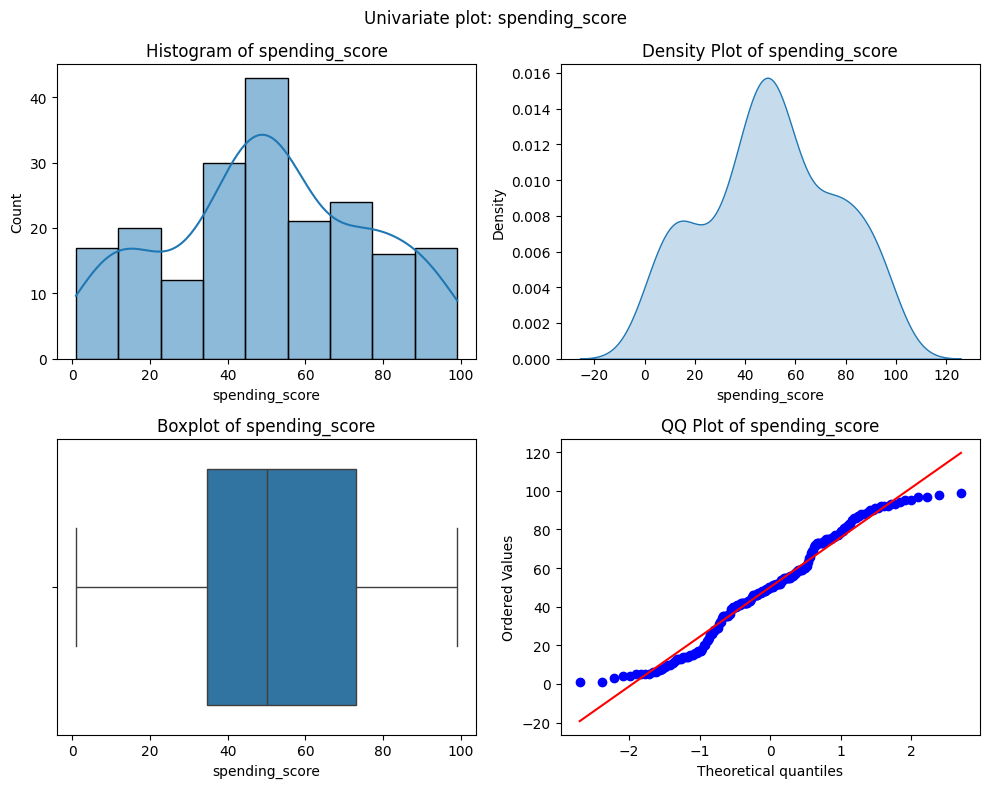

In [82]:
for feature in numerical_features:
    univariate_numerical_plots(df, feature)

from the univariate analysis it is found that lightly right skewed
- so we need to to feature transformation suitably, log transformation or yeo-johnson
- outliers are not found in any numerical features except in annual income (1), presumably the not a anomaly but the normal data

---

#### Categorical Features

In [83]:
def univariate_categorical_plots(data: pd.DataFrame, categorical_features: list[str]) -> dict:
    for i, feature in enumerate(categorical_features):
        fig, axes = plt.subplots(ncols = 2, nrows = len(feature) // ncols)
        sns.countplots( data = data, x = feature)
        plt.title(f"Count Plot: {feature}")
        
    plt.suptitle("Univariate plots of Categorical features")
    plt.tight_layout()
    plt.show()

In [84]:
def univariate_categorical_plots(data: pd.DataFrame, categorical_features: list[str]) -> None:
    ncols = 2
    nrows = (len(categorical_features) + ncols - 1) // ncols
    
    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(12, 6*nrows))
    
    for i, feature in enumerate(categorical_features):
        if nrows == 1:  # if there's only one row
            ax = axes[i % ncols]
        else:
            ax = axes[i // ncols, i % ncols]
        
        sns.countplot(data=data, x=feature, ax=ax)
        ax.set_title(f"Count Plot: {feature}")
    
    # hide any unused subplots
    for i in range(len(categorical_features), nrows * ncols):
        if nrows == 1:
            ax = axes[i % ncols]
        else:
            ax = axes[i // ncols, i % ncols]
        ax.axis('off')
    
    plt.suptitle("Univariate plots of Categorical features")
    plt.tight_layout()
    
    plt.show()


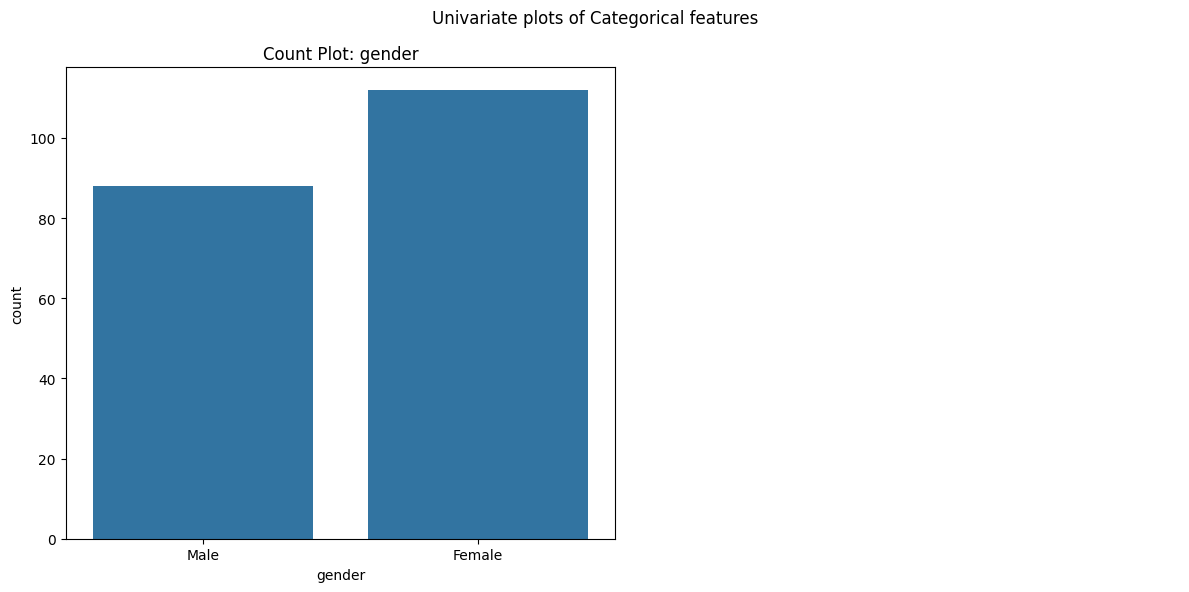

In [85]:
univariate_categorical_plots(df, categorical_features)

from the count plot we could see that :
- Gender is slightly imbalanced: Female (112) vs Male (88) → for clustering, this is usually fine since clustering is unsupervised
- or we could use clustering algorithm robust to outliers such as DBSCAN

---

### 1.2 Bivariate Analysis

#### Numerical vs Numerical

In [86]:
def correlation_matrix(data: pd.DataFrame, numerical_features: list[str]) -> dict:
    correlation_values = {}
    correlation_values['pearson_correlation'] = df[numerical_features].corr(method='pearson')
    correlation_values['spearman_correlation'] = df[numerical_features].corr(method='spearman')
    correlation_values['kendall_correlation'] = df[numerical_features].corr(method='kendall')
    return correlation_values


##### **Pearson's Correlation matrix**

In [87]:
correlation_matrix(df, numerical_features)['pearson_correlation']

,age,annual_income,spending_score
age,1.000000,-0.012398,-0.327227
annual_income,-0.012398,1.000000,0.009903
spending_score,-0.327227,0.009903,1.000000


##### **Pearson's Correlation matrix**

In [88]:
correlation_matrix(df, numerical_features)['spearman_correlation']

,age,annual_income,spending_score
age,1.000000,0.019767,-0.34494
annual_income,0.019767,1.000000,0.00784
spending_score,-0.344940,0.007840,1.00000


##### **Pearson's Correlation matrix**

In [89]:
correlation_matrix(df, numerical_features)['kendall_correlation']

,age,annual_income,spending_score
age,1.000000,0.008198,-0.210757
annual_income,0.008198,1.000000,-0.000765
spending_score,-0.210757,-0.000765,1.000000


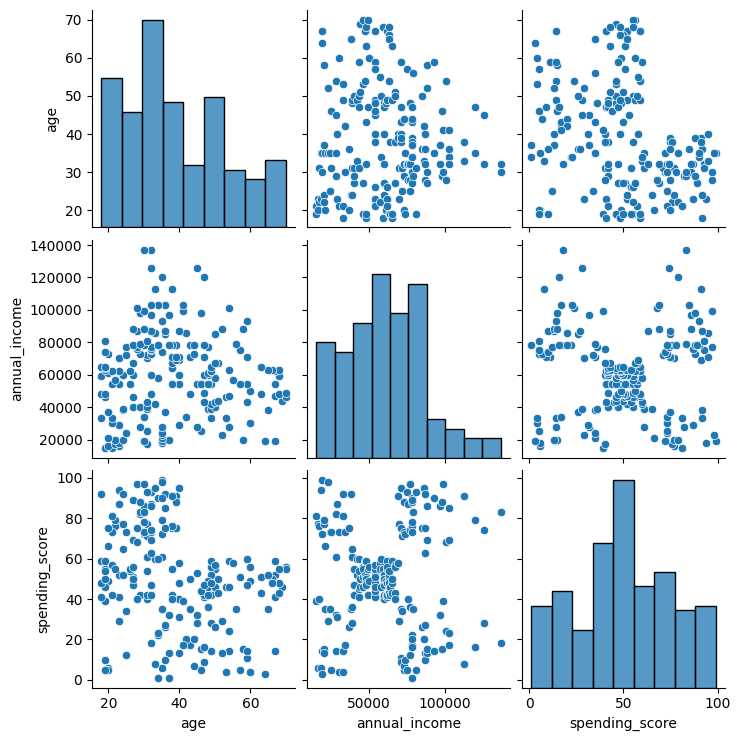

In [90]:
# Pairplot
sns.pairplot(df[numerical_features])
plt.show()


#### Numerical vs Categorical

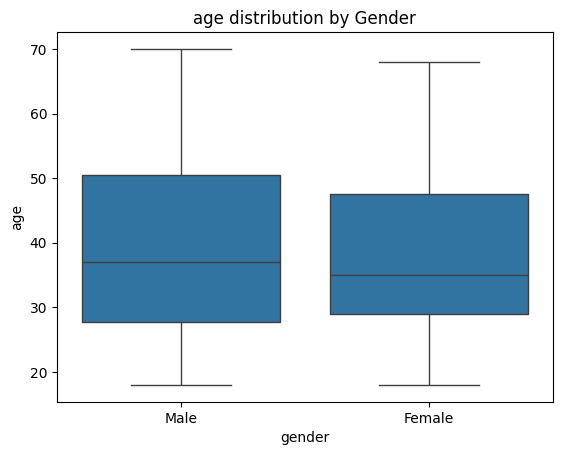

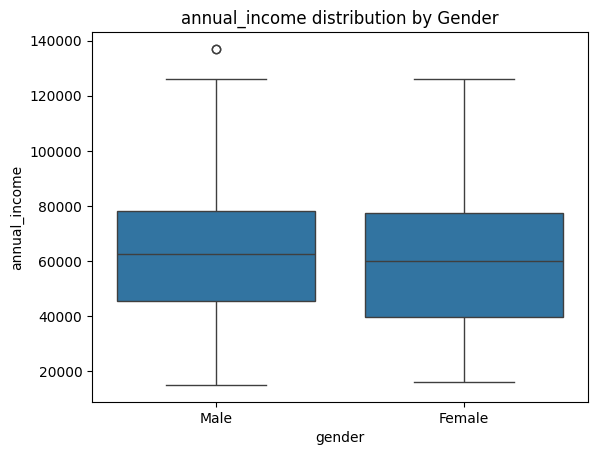

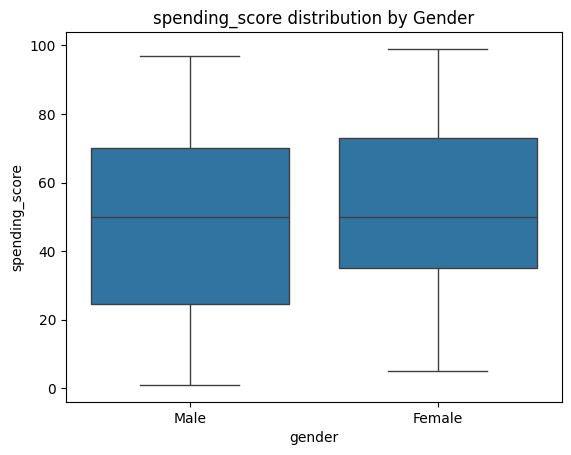

In [91]:
# Boxplots by Gender
for col in numerical_features:
    sns.boxplot(x='gender', y=col, data=df)
    plt.title(f"{col} distribution by Gender")
    plt.show()


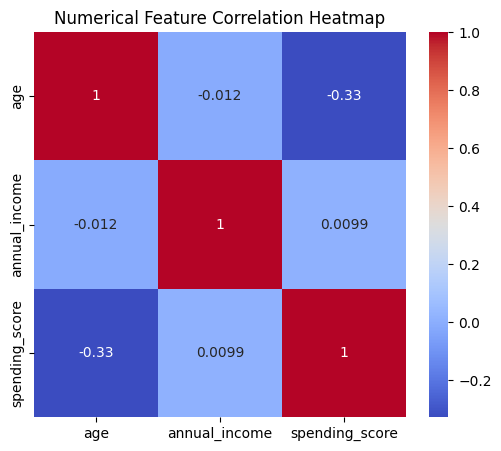

In [92]:
# Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.title("Numerical Feature Correlation Heatmap")
plt.show()


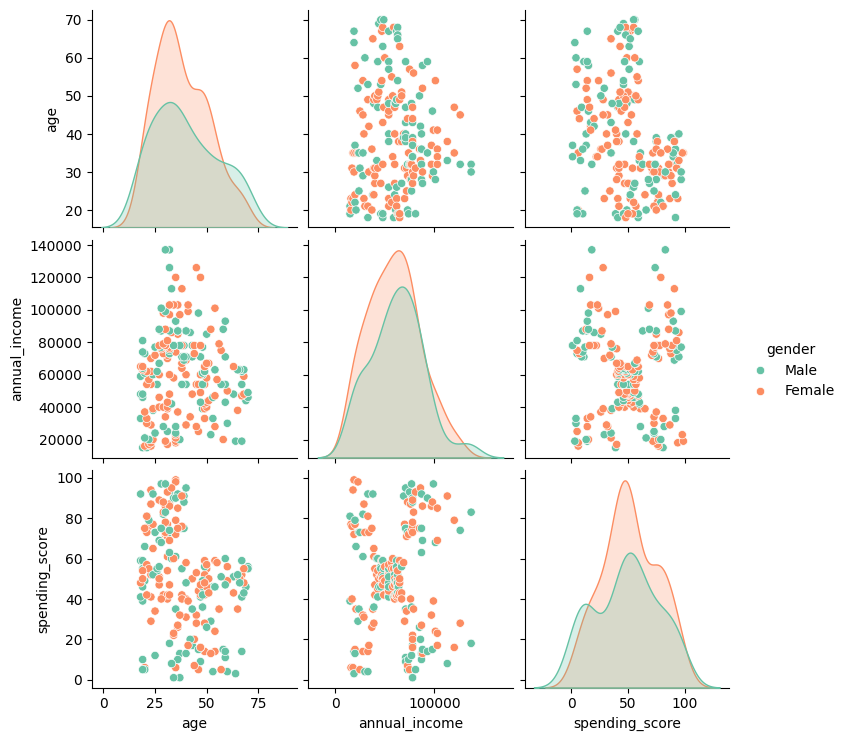

In [93]:
# Pairplot including Gender (optional for categorical insight)
sns.pairplot(df, vars=numerical_features, hue='gender', palette='Set2')
plt.show()


Next Steps / Observations from EDA

Numerical features have mild skew → can scale using StandardScaler or MinMaxScaler

Gender can be one-hot encoded for clustering if desired

No extreme outliers → no need for removal but scaling recommended

Correlations are low → all numerical features can be included

In [94]:
df

,gender,age,annual_income,spending_score
0,Male,19,15000,39
1,Male,21,15000,81
2,Female,20,16000,6
3,Female,23,16000,77
4,Female,31,17000,40
...,...,...,...,...
195,Female,35,120000,79
196,Female,45,126000,28
197,Male,32,126000,74
198,Male,32,137000,18


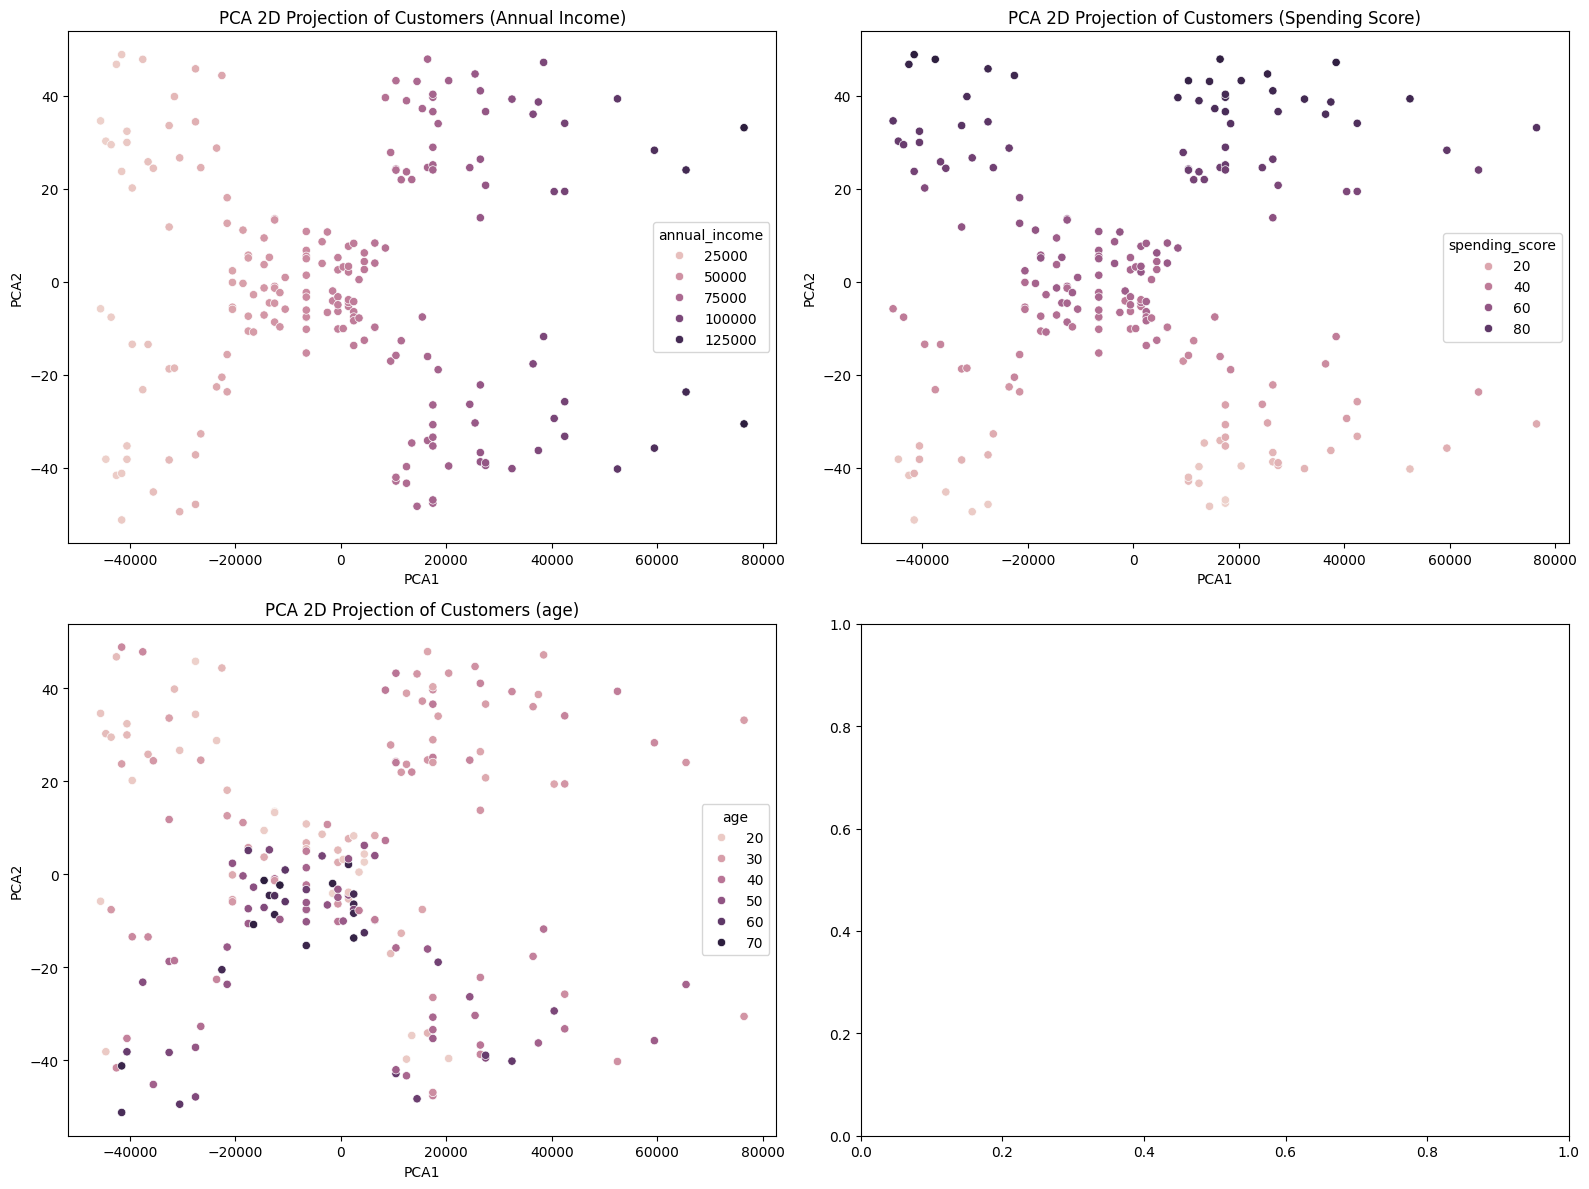

In [95]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df.copy(deep=True)[numerical_features])

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))  # Increased figsize height to accommodate 2x2 subplots

sns.scatterplot(x='PCA1', y='PCA2', hue='annual_income', data=df, ax=axs[0, 0])
axs[0, 0].set_title("PCA 2D Projection of Customers (Annual Income)")

sns.scatterplot(x='PCA1', y='PCA2', hue='spending_score', data=df, ax=axs[0, 1])
axs[0, 1].set_title("PCA 2D Projection of Customers (Spending Score)")

sns.scatterplot(x='PCA1', y='PCA2', hue='age', data=df, ax=axs[1, 0])
axs[1, 0].set_title("PCA 2D Projection of Customers (age)")
"""
sns.scatterplot(x='PCA1', y='PCA2', hue='gender_Male', data=df, ax=axs[1, 1])
axs[1, 1].set_title("PCA 2D Projection of Customers (gender_Male)")
"""
plt.tight_layout()  # Added to ensure subplots fit well in the figure
plt.show()

---

In [96]:
from sklearn.preprocessing import OneHotEncoder

## Feature Engineering

### 2. 1 Missing Value Imputation

### 2. 2. Outlier Handling

### 2. 3.  Encoding Categorical Features

In [97]:
# One-hot encode Gender
encoder = OneHotEncoder(drop='first', sparse_output=False)
gender_encoded = encoder.fit_transform(df[['gender']])

# Get the column names from the encoder
gender_columns = encoder.get_feature_names_out()

# Create a DataFrame from the encoded data
gender_df = pd.DataFrame(gender_encoded, columns=gender_columns)

# Merge with original dataframe
df_encoded = pd.concat([df.drop('gender', axis=1), gender_df], axis=1)


In [98]:
df_encoded

,age,annual_income,spending_score,PCA1,PCA2,gender_Male
0,19,15000,39,-45559.999975,-5.836253,1.0
1,21,15000,81,-45559.999579,34.579234,1.0
2,20,16000,6,-44560.000303,-38.193379,0.0
3,23,16000,77,-44559.999631,30.215611,0.0
4,31,17000,40,-43560.000045,-7.643526,0.0
...,...,...,...,...,...,...
195,35,120000,79,59440.000302,28.260419,0.0
196,45,126000,28,65439.999739,-23.738507,0.0
197,32,126000,74,65440.000272,24.017997,1.0
198,32,137000,18,76439.999726,-30.603228,1.0


### 2.4. Scaling Numerical Features

```Markdown

clustering algorithms often rely on distance-based similarity measures, which can be influenced by the scale of the features.

If one feature has a much larger range than others, it can dominate the distance calculations and affect the clustering results.

Normalizing or standardizing the features can help mitigate this issue by:

1. Reducing the impact of feature scales
2. Ensuring that all features contribute equally to the distance calculations
3. Improving the overall quality of the clustering results

Common techniques for normalization and standardization include:

1. Min-Max Scaling (Normalization)
2. Standardization (Zero-Mean, Unit Variance)
3. Log Scaling

```

In [99]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(df_encoded[numerical_features])

# Replace original columns with scaled values
df_encoded[numerical_features] = numerical_scaled
df_encoded.head()


,age,annual_income,spending_score,PCA1,PCA2,gender_Male
0,-1.424569,-1.738999,-0.434801,-45559.999975,-5.836253,1.0
1,-1.281035,-1.738999,1.195704,-45559.999579,34.579234,1.0
2,-1.352802,-1.700830,-1.715913,-44560.000303,-38.193379,0.0
3,-1.137502,-1.700830,1.040418,-44559.999631,30.215611,0.0
4,-0.563369,-1.662660,-0.395980,-43560.000045,-7.643526,0.0


```markdown

Here we use:
** StandardScaler **→ `mean=0`, `std=1`

All features contribute equally to distance calculations

In [100]:
df_encoded.to_csv(DATA_DIR/'processed_data'/ 'processed_customer_data_version_01.csv', index=False)

### 2.5 Dimensionality Reduction (optional)

In [101]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

df_temp = df_encoded.copy(deep=True)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_temp[numerical_features])


gender_Male

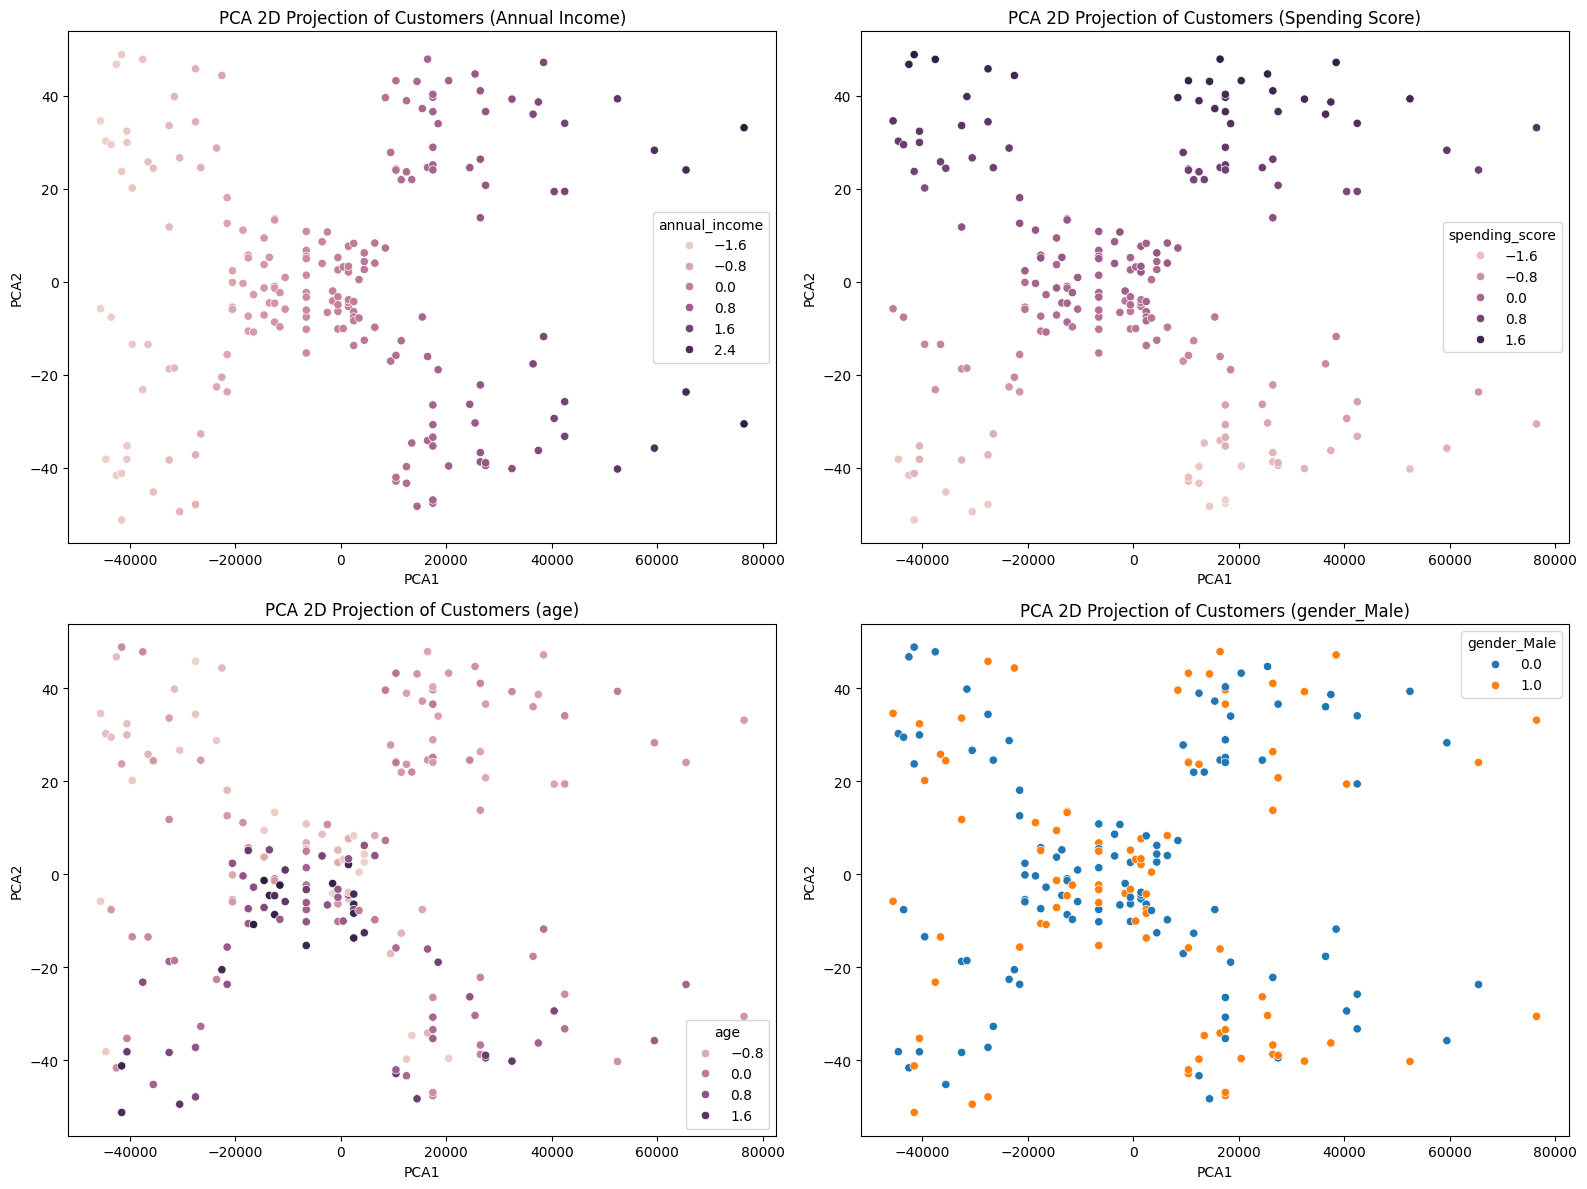

In [102]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))  # Increased figsize height to accommodate 2x2 subplots

sns.scatterplot(x='PCA1', y='PCA2', hue='annual_income', data=df_encoded, ax=axs[0, 0])
axs[0, 0].set_title("PCA 2D Projection of Customers (Annual Income)")

sns.scatterplot(x='PCA1', y='PCA2', hue='spending_score', data=df_encoded, ax=axs[0, 1])
axs[0, 1].set_title("PCA 2D Projection of Customers (Spending Score)")

sns.scatterplot(x='PCA1', y='PCA2', hue='age', data=df_encoded, ax=axs[1, 0])
axs[1, 0].set_title("PCA 2D Projection of Customers (age)")

sns.scatterplot(x='PCA1', y='PCA2', hue='gender_Male', data=df_encoded, ax=axs[1, 1])
axs[1, 1].set_title("PCA 2D Projection of Customers (gender_Male)")

plt.tight_layout()  # Added to ensure subplots fit well in the figure
plt.show()



- PCA can help visualize clusters in 2D or 3D. but in this case, it is not mandatory for 3–5 features but useful for visualization
- Can visually inspect latent clusters before running algorithms
- Useful for sanity check and presentations

---

### 2. 5. Feature Engineering Ideas

In [103]:
df_2 = df.copy(deep=True)
df_2

,gender,age,annual_income,spending_score,PCA1,PCA2
0,Male,19,15000,39,-45559.999975,-5.836253
1,Male,21,15000,81,-45559.999579,34.579234
2,Female,20,16000,6,-44560.000303,-38.193379
3,Female,23,16000,77,-44559.999631,30.215611
4,Female,31,17000,40,-43560.000045,-7.643526
...,...,...,...,...,...,...
195,Female,35,120000,79,59440.000302,28.260419
196,Female,45,126000,28,65439.999739,-23.738507
197,Male,32,126000,74,65440.000272,24.017997
198,Male,32,137000,18,76439.999726,-30.603228


In [104]:
bin_labels = {
    (0, 18, 25, 40, 60, 100): ['teen', 'young_adult', 'adult', 'middle_age', 'seniors'], # binning for age
    (0, 15000, 41500, 78000, 110000): ['low-income', 'middle-income', 'high-income', 'affluent'], # binning for annual_income
    (0, 15000, 41500, 61500, 78000, 90000, 1200000): ['low-income', 'lower-middle-income', 'middle-income', 'upper-middle-income', 'high-income', 'affluent'] # binning for annual_income
}

# exmaple: get the bins and labales later for binning
first_bin = list(bin_labels.keys())[0]
first_labels = list(bin_labels.values())[0]
print(f"{first_bin} = {first_labels}")

(0, 18, 25, 40, 60, 100) = ['teen', 'young_adult', 'adult', 'middle_age', 'seniors']


Age Groups

In [105]:
df_2['age_group'] = pd.cut(
    df_2['age'],
    bins = list(bin_labels.keys())[0],
    labels = list(bin_labels.values())[0]
)

Income Category

In [106]:
df_2['income_level'] = pd.cut(
    df_2['annual_income'], 
    bins=list(bin_labels.keys())[1], 
    labels=list(bin_labels.values())[1])


In [107]:
df_2

,gender,age,annual_income,spending_score,PCA1,PCA2,age_group,income_level
0,Male,19,15000,39,-45559.999975,-5.836253,young_adult,low-income
1,Male,21,15000,81,-45559.999579,34.579234,young_adult,low-income
2,Female,20,16000,6,-44560.000303,-38.193379,young_adult,middle-income
3,Female,23,16000,77,-44559.999631,30.215611,young_adult,middle-income
4,Female,31,17000,40,-43560.000045,-7.643526,adult,middle-income
...,...,...,...,...,...,...,...,...
195,Female,35,120000,79,59440.000302,28.260419,adult,NaN
196,Female,45,126000,28,65439.999739,-23.738507,middle_age,NaN
197,Male,32,126000,74,65440.000272,24.017997,adult,NaN
198,Male,32,137000,18,76439.999726,-30.603228,adult,NaN


#### save the new added features as new version of data

In [108]:
df_2.to_csv(DATA_DIR/'data_versions'/ 'customer_data_version_02.csv', index=False)


---

# Part 3: Train multiple clustering algorithms with CV & internal metrics

In [109]:
import sklearn
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
import hdbscan

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import optuna

In [110]:
# Optional: HDBSCAN (install separately if you want to use it)
try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception:
    HDBSCAN_AVAILABLE = False

In [111]:
# For safety, if df_encoded exists in runtime use it, otherwise try to load preprocessed CSV
try:
    df_encoded  # noqa: F821
except NameError:
    df_encoded = pd.read_csv(DATA_DIR /"processed_data" / "processed_customer_data_version_01.csv")  # path you saved earlier

In [112]:
df_encoded

,age,annual_income,spending_score,PCA1,PCA2,gender_Male
0,-1.424569,-1.738999,-0.434801,-45559.999975,-5.836253,1.0
1,-1.281035,-1.738999,1.195704,-45559.999579,34.579234,1.0
2,-1.352802,-1.700830,-1.715913,-44560.000303,-38.193379,0.0
3,-1.137502,-1.700830,1.040418,-44559.999631,30.215611,0.0
4,-0.563369,-1.662660,-0.395980,-43560.000045,-7.643526,0.0
...,...,...,...,...,...,...
195,-0.276302,2.268791,1.118061,59440.000302,28.260419,0.0
196,0.441365,2.497807,-0.861839,65439.999739,-23.738507,0.0
197,-0.491602,2.497807,0.923953,65440.000272,24.017997,1.0
198,-0.491602,2.917671,-1.250054,76439.999726,-30.603228,1.0


---

In [113]:
df_encoded.columns

Index(['age', 'annual_income', 'spending_score', 'PCA1', 'PCA2',
       'gender_Male'],
      dtype='object')

In [114]:
# Define clustering algorithms
algorithms = {
    'kmeans': KMeans(n_clusters=2),
    'dbscan': DBSCAN(eps=0.3, min_samples=10),
    'agg': AgglomerativeClustering(n_clusters=2),
    'gmm': GaussianMixture(n_components=2),
    'spectral': SpectralClustering(n_clusters=2),
    'hdbscan': hdbscan.HDBSCAN(min_samples=10)
}


In [115]:
data = df_encoded.drop(columns=['PCA1', 'PCA2'], axis=1)
data

,age,annual_income,spending_score,gender_Male
0,-1.424569,-1.738999,-0.434801,1.0
1,-1.281035,-1.738999,1.195704,1.0
2,-1.352802,-1.700830,-1.715913,0.0
3,-1.137502,-1.700830,1.040418,0.0
4,-0.563369,-1.662660,-0.395980,0.0
...,...,...,...,...
195,-0.276302,2.268791,1.118061,0.0
196,0.441365,2.497807,-0.861839,0.0
197,-0.491602,2.497807,0.923953,1.0
198,-0.491602,2.917671,-1.250054,1.0


Algorithm: kmeans
Silhouette Coefficient: 0.562
Calinski-Harabasz Index: 360.577
Davies-Bouldin Index: 0.585

        age  annual_income  spending_score          PCA1       PCA2  \
0 -1.424569      -1.738999       -0.434801 -45559.999975  -5.836253   
1 -1.281035      -1.738999        1.195704 -45559.999579  34.579234   
2 -1.352802      -1.700830       -1.715913 -44560.000303 -38.193379   
3 -1.137502      -1.700830        1.040418 -44559.999631  30.215611   
4 -0.563369      -1.662660       -0.395980 -43560.000045  -7.643526   

   gender_Male  cluster_id  
0          1.0           0  
1          1.0           0  
2          0.0           0  
3          0.0           0  
4          0.0           0  


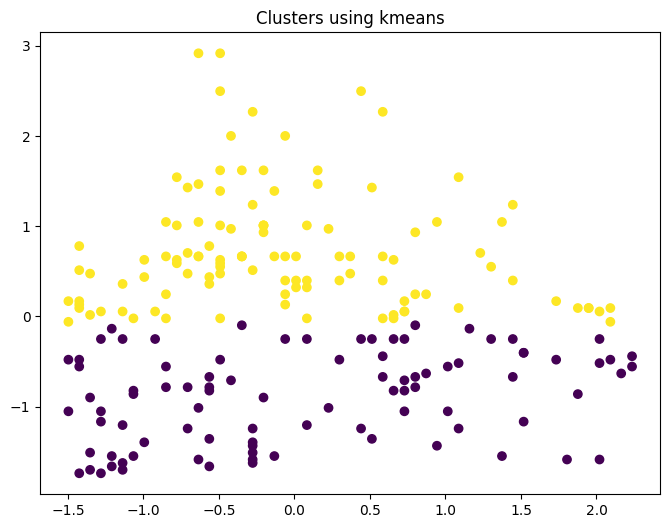

        age  annual_income  spending_score          PCA1       PCA2  \
0 -1.424569      -1.738999       -0.434801 -45559.999975  -5.836253   
1 -1.281035      -1.738999        1.195704 -45559.999579  34.579234   
2 -1.352802      -1.700830       -1.715913 -44560.000303 -38.193379   
3 -1.137502      -1.700830        1.040418 -44559.999631  30.215611   
4 -0.563369      -1.662660       -0.395980 -43560.000045  -7.643526   

   gender_Male  cluster_id  
0          1.0          -1  
1          1.0          -1  
2          0.0          -1  
3          0.0          -1  
4          0.0          -1  


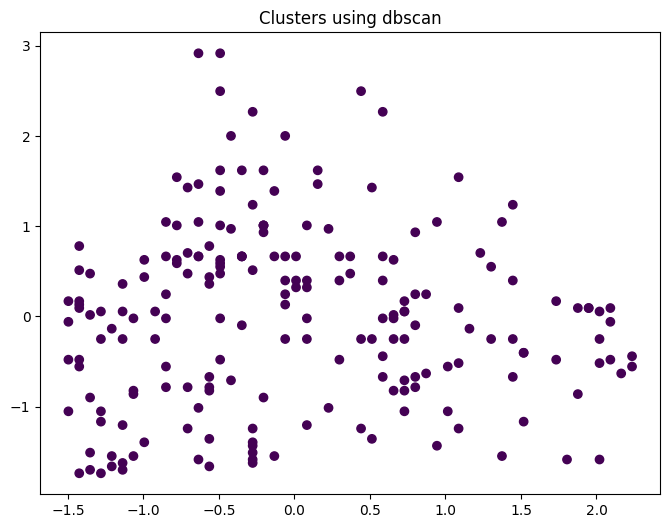

Algorithm: agg
Silhouette Coefficient: 0.561
Calinski-Harabasz Index: 333.065
Davies-Bouldin Index: 0.557

        age  annual_income  spending_score          PCA1       PCA2  \
0 -1.424569      -1.738999       -0.434801 -45559.999975  -5.836253   
1 -1.281035      -1.738999        1.195704 -45559.999579  34.579234   
2 -1.352802      -1.700830       -1.715913 -44560.000303 -38.193379   
3 -1.137502      -1.700830        1.040418 -44559.999631  30.215611   
4 -0.563369      -1.662660       -0.395980 -43560.000045  -7.643526   

   gender_Male  cluster_id  
0          1.0           1  
1          1.0           1  
2          0.0           1  
3          0.0           1  
4          0.0           1  


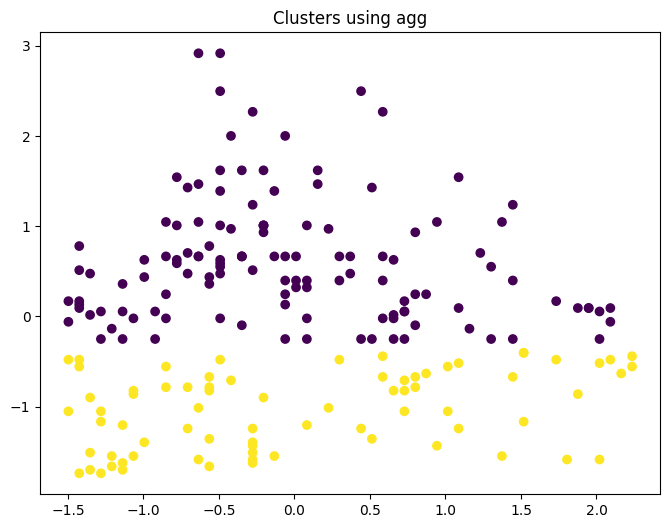

Algorithm: gmm
Silhouette Coefficient: 0.432
Calinski-Harabasz Index: 247.958
Davies-Bouldin Index: 0.718

        age  annual_income  spending_score          PCA1       PCA2  \
0 -1.424569      -1.738999       -0.434801 -45559.999975  -5.836253   
1 -1.281035      -1.738999        1.195704 -45559.999579  34.579234   
2 -1.352802      -1.700830       -1.715913 -44560.000303 -38.193379   
3 -1.137502      -1.700830        1.040418 -44559.999631  30.215611   
4 -0.563369      -1.662660       -0.395980 -43560.000045  -7.643526   

   gender_Male  cluster_id  
0          1.0           0  
1          1.0           0  
2          0.0           0  
3          0.0           0  
4          0.0           0  


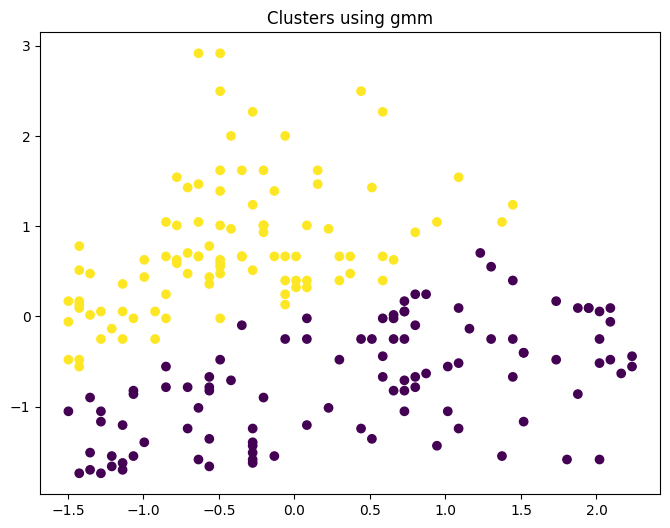

Algorithm: spectral
Silhouette Coefficient: -0.304
Calinski-Harabasz Index: 0.158
Davies-Bouldin Index: 2.007

        age  annual_income  spending_score          PCA1       PCA2  \
0 -1.424569      -1.738999       -0.434801 -45559.999975  -5.836253   
1 -1.281035      -1.738999        1.195704 -45559.999579  34.579234   
2 -1.352802      -1.700830       -1.715913 -44560.000303 -38.193379   
3 -1.137502      -1.700830        1.040418 -44559.999631  30.215611   
4 -0.563369      -1.662660       -0.395980 -43560.000045  -7.643526   

   gender_Male  cluster_id  
0          1.0           0  
1          1.0           0  
2          0.0           0  
3          0.0           0  
4          0.0           0  


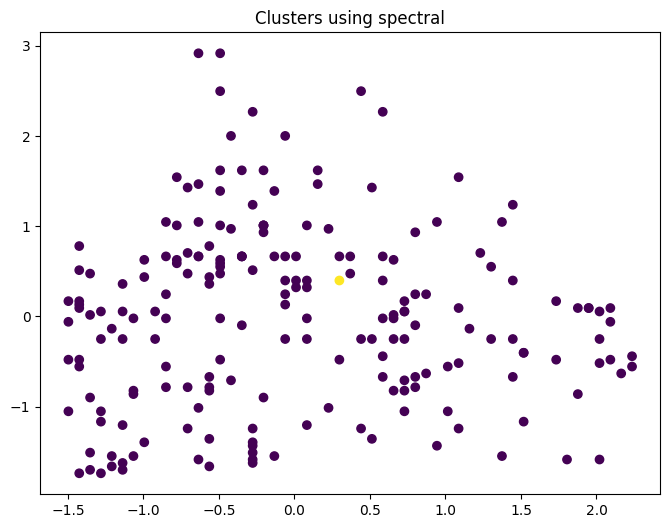

Algorithm: hdbscan
Silhouette Coefficient: 0.441
Calinski-Harabasz Index: 52.020
Davies-Bouldin Index: 4.817

        age  annual_income  spending_score          PCA1       PCA2  \
0 -1.424569      -1.738999       -0.434801 -45559.999975  -5.836253   
1 -1.281035      -1.738999        1.195704 -45559.999579  34.579234   
2 -1.352802      -1.700830       -1.715913 -44560.000303 -38.193379   
3 -1.137502      -1.700830        1.040418 -44559.999631  30.215611   
4 -0.563369      -1.662660       -0.395980 -43560.000045  -7.643526   

   gender_Male  cluster_id  
0          1.0          -1  
1          1.0          -1  
2          0.0           1  
3          0.0           1  
4          0.0           1  


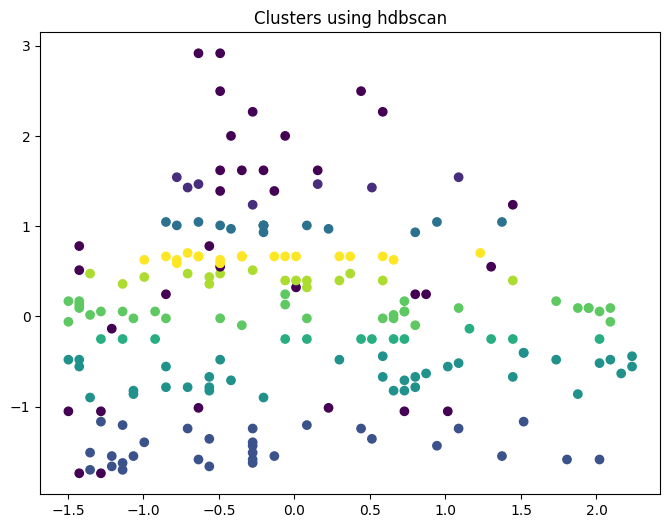

In [122]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Define clustering algorithms
algorithms = {
    'kmeans': KMeans(n_clusters=2),
    'dbscan': DBSCAN(eps=0.3, min_samples=10),
    'agg': AgglomerativeClustering(n_clusters=2),
    'gmm': GaussianMixture(n_components=2),
    'spectral': SpectralClustering(n_clusters=2),
    'hdbscan': hdbscan.HDBSCAN(min_samples=10)
}

# Evaluate clustering algorithms
for name, algorithm in algorithms.items():
    labels = algorithm.fit_predict(df_encoded)
    
    # Calculate evaluation metrics
    if len(set(labels)) > 1:
        silhouette = silhouette_score(df_encoded, labels)
        calinski_harabasz = calinski_harabasz_score(df_encoded, labels)
        davies_bouldin = davies_bouldin_score(df_encoded, labels)
        
        # Print evaluation metrics
        print(f"Algorithm: {name}")
        print(f"Silhouette Coefficient: {silhouette:.3f}")
        print(f"Calinski-Harabasz Index: {calinski_harabasz:.3f}")
        print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")
        print()
    
    # Create a new DataFrame with the cluster ID as the target
    cluster_df = df_encoded.copy()
    cluster_df['cluster_id'] = labels
    
    # Print the new DataFrame
    print(cluster_df.head())
    
    # Plot clusters
    plt.figure(figsize=(8, 6))
    plt.scatter(cluster_df.iloc[:, 0], cluster_df.iloc[:, 1], c=cluster_df['cluster_id'], cmap='viridis')
    plt.title(f"Clusters using {name}")
    plt.show()


In [116]:
type(data)

pandas.core.frame.DataFrame

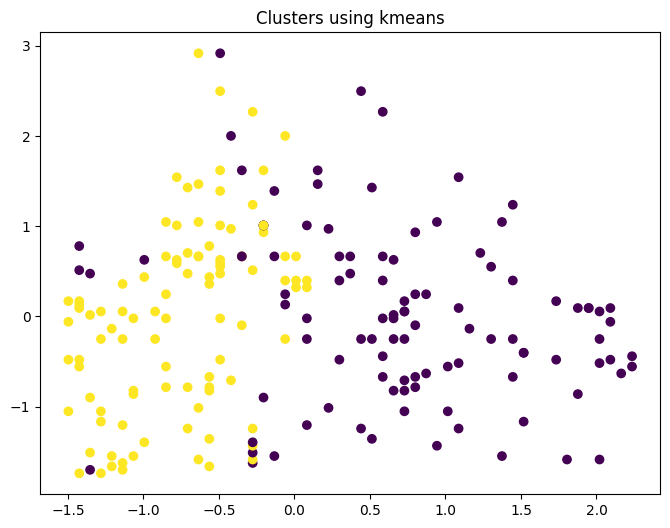

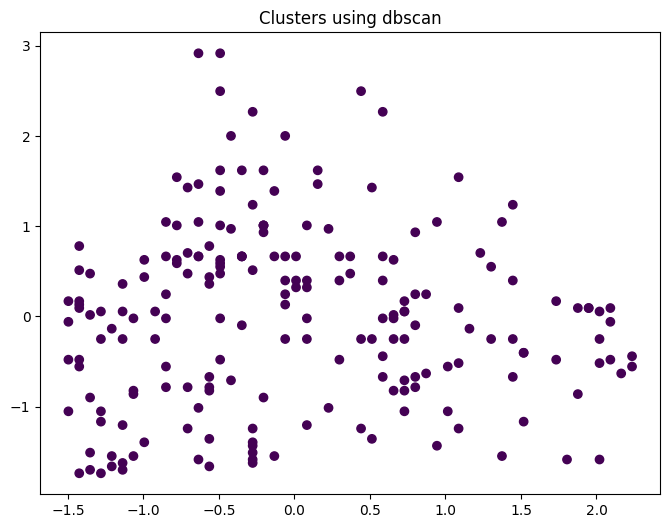

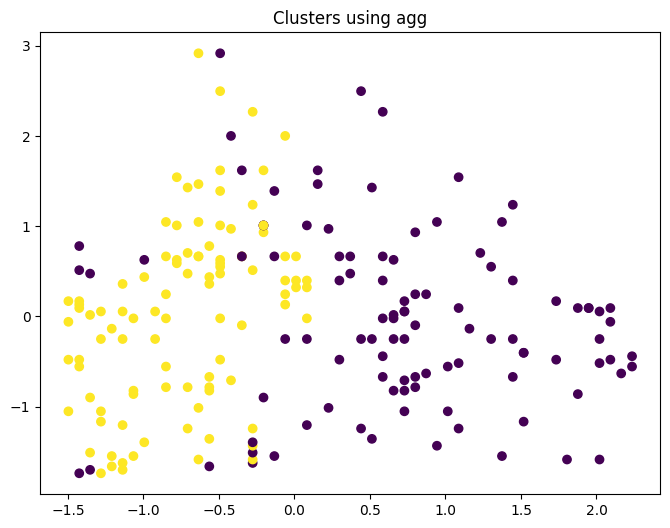

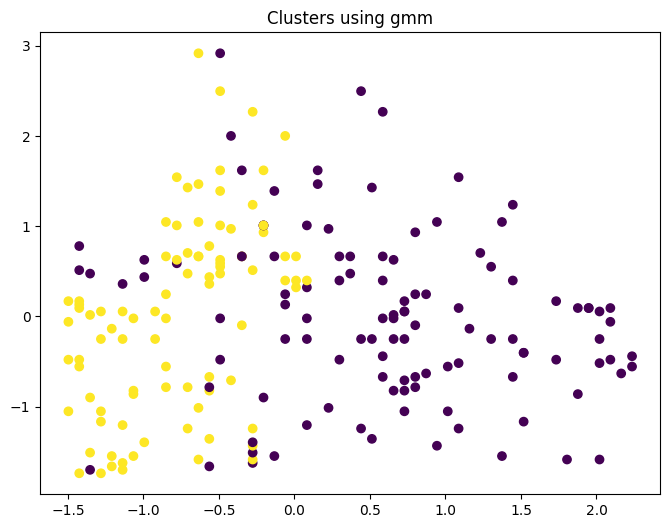

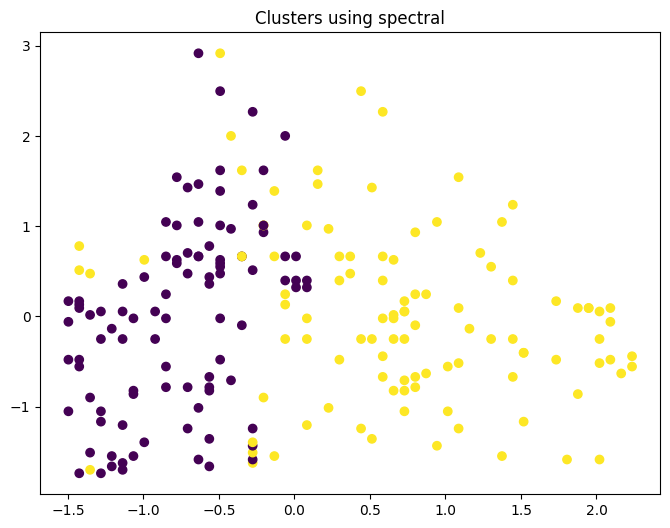

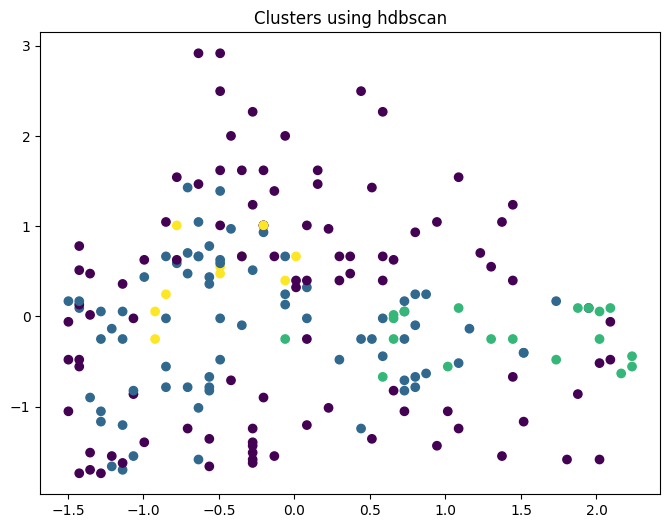

In [117]:
# Apply clustering algorithms
for name, algorithm in algorithms.items():
    labels = algorithm.fit_predict(data)
    
    # Plot clusters
    plt.figure(figsize=(8, 6))
    plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=labels, cmap='viridis')
    plt.title(f"Clusters using {name}")
    plt.show()


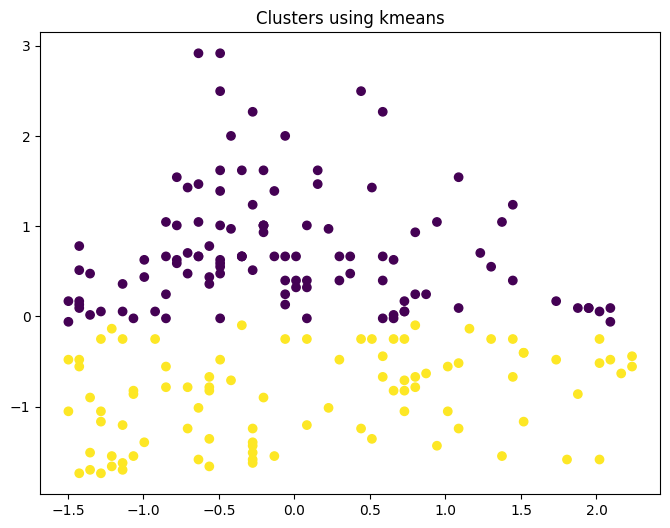

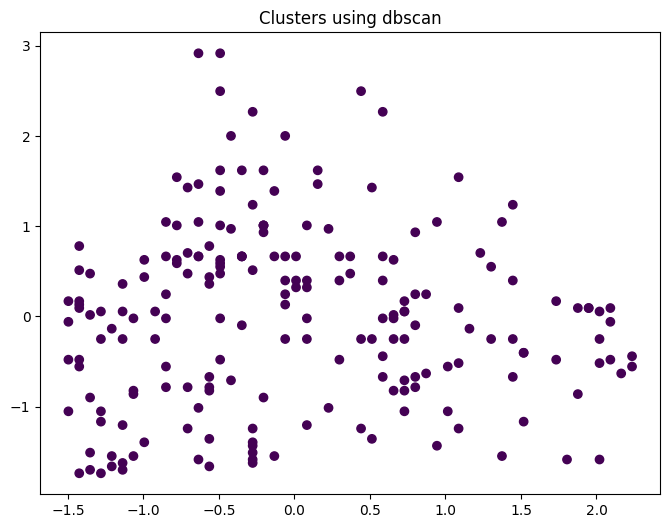

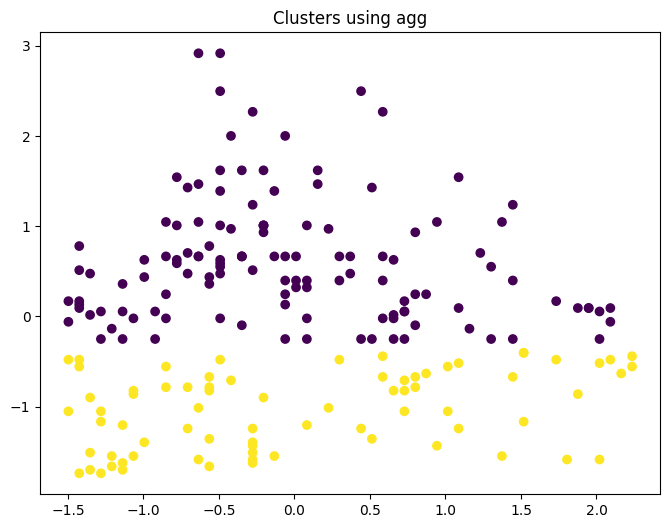

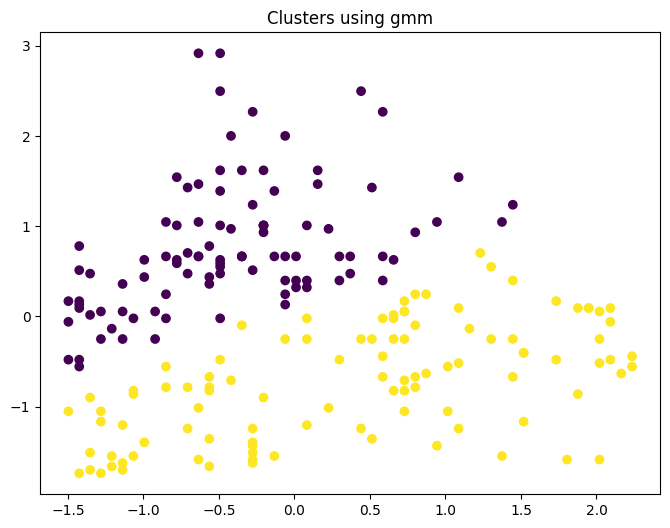

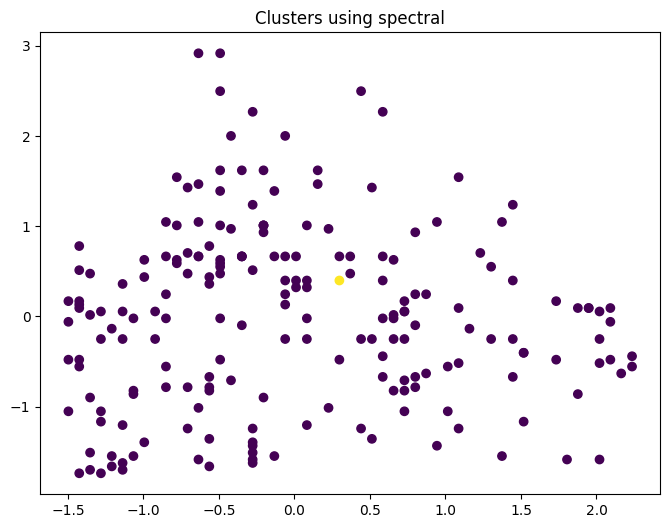

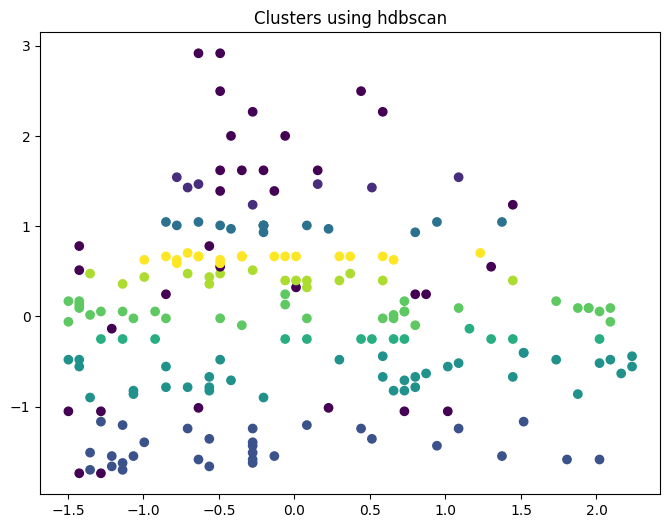

In [118]:
# Apply clustering algorithms
for name, algorithm in algorithms.items():
    labels = algorithm.fit_predict(df_encoded)
    
    # Plot clusters
    plt.figure(figsize=(8, 6))
    plt.scatter(df_encoded.iloc[:, 0], df_encoded.iloc[:, 1], c=labels, cmap='viridis')
    plt.title(f"Clusters using {name}")
    plt.show()


        age  annual_income  spending_score  gender_Male  cluster_id
0 -1.424569      -1.738999       -0.434801          1.0           0
1 -1.281035      -1.738999        1.195704          1.0           0
2 -1.352802      -1.700830       -1.715913          0.0           1
3 -1.137502      -1.700830        1.040418          0.0           0
4 -0.563369      -1.662660       -0.395980          0.0           0


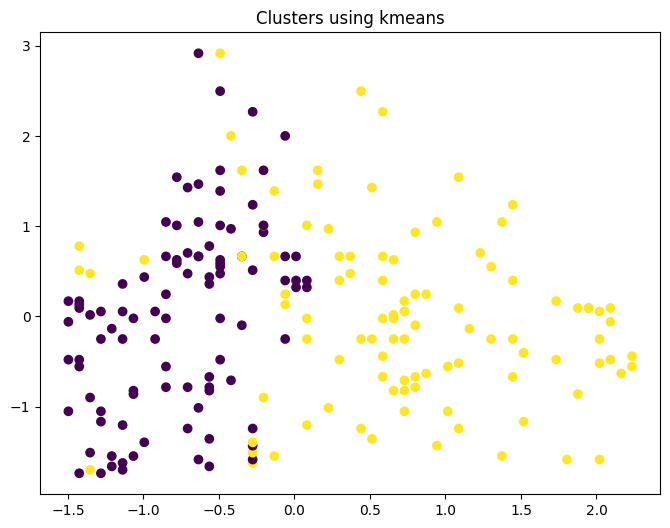

        age  annual_income  spending_score  gender_Male  cluster_id
0 -1.424569      -1.738999       -0.434801          1.0          -1
1 -1.281035      -1.738999        1.195704          1.0          -1
2 -1.352802      -1.700830       -1.715913          0.0          -1
3 -1.137502      -1.700830        1.040418          0.0          -1
4 -0.563369      -1.662660       -0.395980          0.0          -1


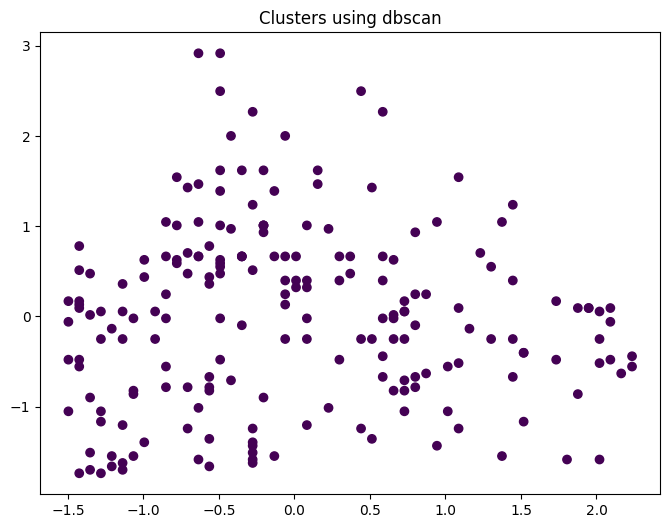

        age  annual_income  spending_score  gender_Male  cluster_id
0 -1.424569      -1.738999       -0.434801          1.0           0
1 -1.281035      -1.738999        1.195704          1.0           1
2 -1.352802      -1.700830       -1.715913          0.0           0
3 -1.137502      -1.700830        1.040418          0.0           1
4 -0.563369      -1.662660       -0.395980          0.0           0


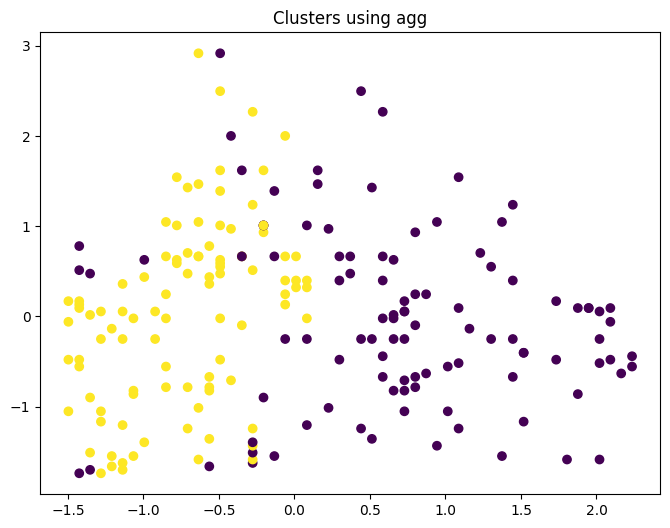

        age  annual_income  spending_score  gender_Male  cluster_id
0 -1.424569      -1.738999       -0.434801          1.0           1
1 -1.281035      -1.738999        1.195704          1.0           1
2 -1.352802      -1.700830       -1.715913          0.0           0
3 -1.137502      -1.700830        1.040418          0.0           1
4 -0.563369      -1.662660       -0.395980          0.0           0


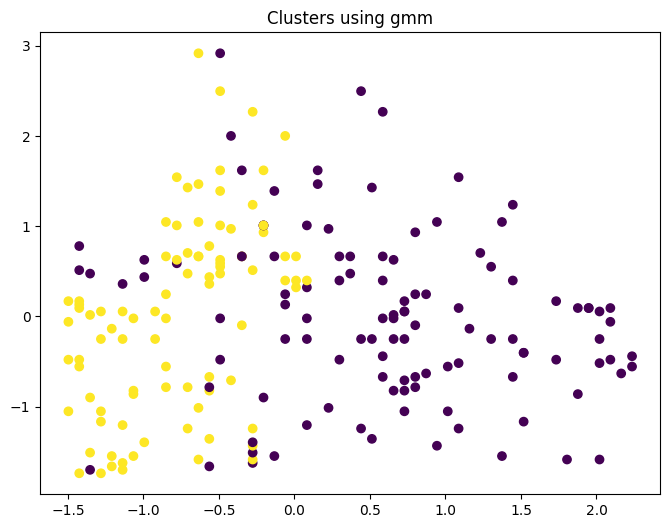

        age  annual_income  spending_score  gender_Male  cluster_id
0 -1.424569      -1.738999       -0.434801          1.0           1
1 -1.281035      -1.738999        1.195704          1.0           1
2 -1.352802      -1.700830       -1.715913          0.0           0
3 -1.137502      -1.700830        1.040418          0.0           1
4 -0.563369      -1.662660       -0.395980          0.0           1


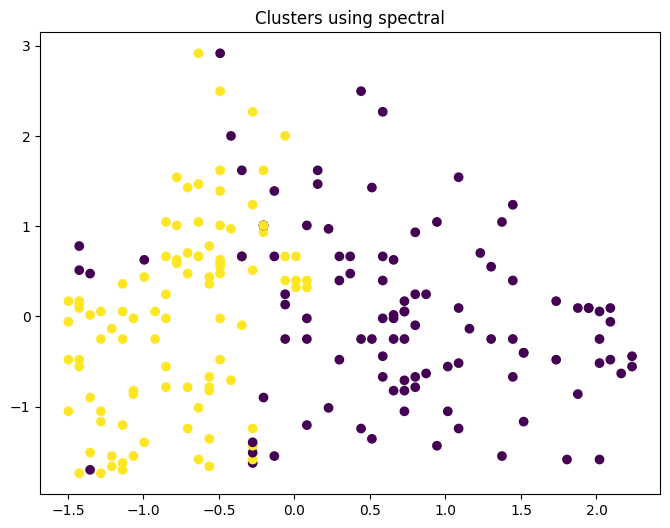

        age  annual_income  spending_score  gender_Male  cluster_id
0 -1.424569      -1.738999       -0.434801          1.0          -1
1 -1.281035      -1.738999        1.195704          1.0          -1
2 -1.352802      -1.700830       -1.715913          0.0          -1
3 -1.137502      -1.700830        1.040418          0.0           0
4 -0.563369      -1.662660       -0.395980          0.0          -1


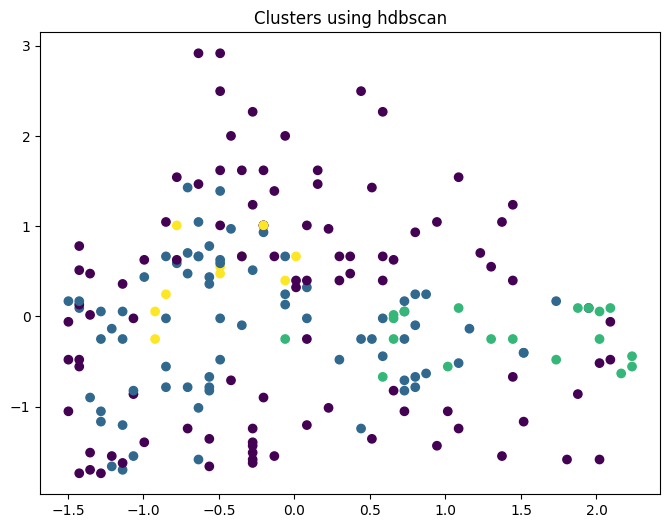

In [119]:
# Apply clustering algorithms
for name, algorithm in algorithms.items():
    labels = algorithm.fit_predict(data)
    
    # Create a new DataFrame with the cluster ID as the target
    cluster_df = data.copy()
    cluster_df['cluster_id'] = labels
    
    # Print the new DataFrame
    print(cluster_df.head())
    
    # Plot clusters
    plt.figure(figsize=(8, 6))
    plt.scatter(cluster_df.iloc[:, 0], cluster_df.iloc[:, 1], c=cluster_df['cluster_id'], cmap='viridis')
    plt.title(f"Clusters using {name}")
    plt.show()


In [124]:

# KMeans

param_grid_kmeans = {
    'n_clusters': [2, 3, 4, 5, 6],
    'init': ['k-means++', 'random'],
    'max_iter': [100, 200, 300],
    'n_init': [10, 20, 30]
}

# DBSCAN

param_grid_dbscan = {
    'eps': [0.1, 0.2, 0.3, 0.4, 0.5],
    'min_samples': [5, 10, 15, 20],
    'metric': ['euclidean', 'manhattan']
}
# AgglomerativeClustering

param_grid_agg = {
    'n_clusters': [2, 3, 4, 5, 6],
    'affinity': ['euclidean', 'manhattan'],
    'linkage': ['ward', 'complete', 'average']
}


# GaussianMixture

param_grid_gmm = {
    'n_components': [2, 3, 4, 5, 6],
    'covariance_type': ['full', 'tied', 'diag', 'spherical'],
    'max_iter': [100, 200, 300],
    'n_init': [10, 20, 30]
}
# SpectralClustering

param_grid_spectral = {
    'n_clusters': [2, 3, 4, 5, 6],
    'eigen_solver': ['arpack', 'lobpcg'],
    'affinity': ['rbf', 'nearest_neighbors']
}
# HDBSCAN

param_grid_hdbscan = {
    'min_samples': [5, 10, 15, 20],
    'min_cluster_size': [5, 10, 15, 20]
}

In [125]:
from sklearn.model_selection import GridSearchCV

# Define clustering algorithms
algorithms = {
    'kmeans': KMeans(),
    'dbscan': DBSCAN(),
    'agg': AgglomerativeClustering(),
    'gmm': GaussianMixture(),
    'spectral': SpectralClustering(),
    'hdbscan': hdbscan.HDBSCAN()
}

# Define parameter grids
param_grids = {
    'kmeans': param_grid_kmeans,
    'dbscan': param_grid_dbscan,
    'agg': param_grid_agg,
    'gmm': param_grid_gmm,
    'spectral': param_grid_spectral,
    'hdbscan': param_grid_hdbscan
}

# Perform hyperparameter tuning
best_models = {}
for name, algorithm in algorithms.items():
    grid_search = GridSearchCV(algorithm, param_grids[name], cv=5, scoring='silhouette')
    grid_search.fit(df_encoded)
    best_models[name] = grid_search.best_estimator_

InvalidParameterError: The 'scoring' parameter of GridSearchCV must be a str among {'roc_auc_ovo_weighted', 'adjusted_mutual_info_score', 'explained_variance', 'f1', 'recall', 'roc_auc_ovr_weighted', 'precision_micro', 'matthews_corrcoef', 'jaccard_weighted', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'neg_mean_squared_log_error', 'homogeneity_score', 'v_measure_score', 'accuracy', 'd2_absolute_error_score', 'neg_mean_poisson_deviance', 'neg_mean_gamma_deviance', 'recall_micro', 'f1_weighted', 'neg_mean_absolute_error', 'precision_weighted', 'neg_log_loss', 'f1_macro', 'roc_auc_ovo', 'neg_brier_score', 'top_k_accuracy', 'adjusted_rand_score', 'average_precision', 'neg_root_mean_squared_error', 'precision', 'recall_samples', 'fowlkes_mallows_score', 'jaccard_micro', 'precision_samples', 'recall_weighted', 'neg_mean_absolute_percentage_error', 'balanced_accuracy', 'neg_max_error', 'jaccard', 'mutual_info_score', 'f1_micro', 'jaccard_macro', 'f1_samples', 'positive

In [ ]:

# Evaluate best models
best_model_scores = {}
for name, model in best_models.items():
    labels = model.fit_predict(df_encoded)
    silhouette = silhouette_score(df_encoded, labels)
    best_model_scores[name] = silhouette

# Select best model
best_model_name = max(best_model_scores, key=best_model_scores.get)
best_model = best_models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Best model silhouette score: {best_model_scores[best_model_name]}")

In [ ]:
# Here's the complete code:


from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score, make_scorer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering
import hdbscan

# Define clustering algorithms
algorithms = {
    'kmeans': KMeans(),
    'dbscan': DBSCAN(),
    'agg': AgglomerativeClustering(),
    'gmm': GaussianMixture(),
    'spectral': SpectralClustering(),
    'hdbscan': hdbscan.HDBSCAN()
}

# Define parameter grids
param_grids = {
    'kmeans': {
        'n_clusters': [2, 3, 4, 5, 6],
        'init': ['k-means++', 'random'],
        'max_iter': [100, 200, 300],
        'n_init': [10, 20, 30]
    },
    'dbscan': {
        'eps': [0.1, 0.2, 0.3, 0.4, 0.5],
        'min_samples': [5, 10, 15, 20],
        'metric': ['euclidean', 'manhattan']
    },
    'agg': {
        'n_clusters': [2, 3, 4, 5, 6],
        'linkage': ['ward', 'complete', 'average']
    },
    'gmm': {
        'n_components': [2, 3, 4, 5, 6],
        'covariance_type': ['full', 'tied', 'diag', 'spherical'],
        'max_iter': [100, 200, 300],
        'n_init': [10, 20, 30]
    },
    'spectral': {
        'n_clusters': [2, 3, 4, 5, 6],
        'eigen_solver': ['arpack', 'lobpcg'],
        'affinity': ['rbf', 'nearest_neighbors']
    },
    'hdbscan': {
        'min_samples': [5, 10, 15, 20],
        'min_cluster_size': [5, 10, 15, 20]
    }
}


# Define custom scoring function
silhouette_scorer = make_scorer(silhouette_score, metric='euclidean')

# Perform hyperparameter tuning
best_models = {}
for name, algorithm in algorithms.items():
    grid_search = GridSearchCV(algorithm, param_grids[name], cv=5, scoring=silhouette_scorer)
    grid_search.fit(df_encoded)
    best_models[name] = grid_search.best_estimator_

# Evaluate best models
best_model_scores = {}
for name, model in best_models.items():
    labels = model.fit_predict(df_encoded)
    silhouette = silhouette_score(df_encoded, labels)
    best_model_scores[name] = silhouette

# Select best model
best_model_name = max(best_model_scores, key=best_model_scores.get)
best_model = best_models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Best model silhouette score: {best_model_scores[best_model_name]}")


In [131]:
# -----------------------
# Part 3: Train multiple clustering algorithms with CV & internal metrics
# -----------------------

# Prereqs: ensure Optuna is installed
# pip install optuna

import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import optuna
import warnings
warnings.filterwarnings("ignore")

# Optional: HDBSCAN (install separately if you want to use it)
try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception:
    HDBSCAN_AVAILABLE = False

# -----------------------
# Inputs (use your preprocessed data here)
# - df_encoded: dataframe after encoding/scaling (or saved file)
# - X_preprocessed: numpy array / feature matrix used for clustering
# Example: if you followed previous steps, X_preprocessed can be:
# X_preprocessed = df_encoded.drop('CustomerID', axis=1).values
# -----------------------

# For safety, if df_encoded exists in runtime use it, otherwise try to load preprocessed CSV
try:
    df_encoded  # noqa: F821
except NameError:
    df_encoded = pd.read_csv("preprocessed_customers.csv")  # path you saved earlier

# Exclude non-feature columns if present (CustomerID)
feature_cols = [c for c in df_encoded.columns if c not in ('CustomerID','PCA1','PCA2','Cluster','Segment')]
X_preprocessed = df_encoded[feature_cols].values

print("Feature shape:", X_preprocessed.shape)
print("Features used:", feature_cols)


# -----------------------
# Internal metrics wrapper
# -----------------------
def compute_internal_metrics(X, labels):
    """Compute silhouette, DBI, CH on non-noise points (exclude label -1)."""
    unique_labels = np.unique(labels)
    # If only single cluster or all noise -> invalid
    mask = labels != -1 if -1 in unique_labels else slice(None)
    labels_masked = labels[mask]
    X_masked = X[mask]
    if len(np.unique(labels_masked)) <= 1:
        return {"silhouette": np.nan, "DBI": np.nan, "CH": np.nan, "n_clusters": len(np.unique(labels_masked))}
    sil = silhouette_score(X_masked, labels_masked)
    dbi = davies_bouldin_score(X_masked, labels_masked)
    ch = calinski_harabasz_score(X_masked, labels_masked)
    return {"silhouette": sil, "DBI": dbi, "CH": ch, "n_clusters": len(np.unique(labels_masked))}


# -----------------------
# Clustering wrapper
# -----------------------
def fit_predict_algorithm(algorithm, X, params):
    """
    Fit and predict labels for an algorithm with given params.
    algorithm: string in {'kmeans','dbscan','agg','gmm','spectral','hdbscan'}
    params: dict of hyperparameters appropriate for the algorithm
    returns: labels (np.array), fitted_model
    """
    algorithm = algorithm.lower()
    if algorithm == 'kmeans':
        model = KMeans(n_clusters=int(params.get('n_clusters', 5)),
                       init=params.get('init','k-means++'),
                       n_init=params.get('n_init',10),
                       max_iter=int(params.get('max_iter',300)),
                       random_state=42)
        labels = model.fit_predict(X)
    elif algorithm == 'dbscan':
        model = DBSCAN(eps=float(params.get('eps',0.8)),
                       min_samples=int(params.get('min_samples',5)),
                       metric=params.get('metric','euclidean'))
        labels = model.fit_predict(X)
    elif algorithm in ('agg','agglomerative'):
        model = AgglomerativeClustering(n_clusters=int(params.get('n_clusters',5)),
                                        linkage=params.get('linkage','ward'))
        labels = model.fit_predict(X)
    elif algorithm == 'gmm':
        model = GaussianMixture(n_components=int(params.get('n_components',5)),
                                covariance_type=params.get('covariance_type','full'),
                                random_state=42)
        labels = model.fit_predict(X)
    elif algorithm == 'spectral':
        model = SpectralClustering(n_clusters=int(params.get('n_clusters',5)),
                                   affinity=params.get('affinity','rbf'),
                                   assign_labels=params.get('assign_labels','kmeans'),
                                   random_state=42)
        labels = model.fit_predict(X)
    elif algorithm == 'hdbscan':
        if not HDBSCAN_AVAILABLE:
            raise RuntimeError("HDBSCAN not available. Install hdbscan to use.")
        model = hdbscan.HDBSCAN(min_cluster_size=int(params.get('min_cluster_size',5)),
                                min_samples=int(params.get('min_samples',None)) if params.get('min_samples') is not None else None,
                                metric=params.get('metric','euclidean'))
        labels = model.fit_predict(X)
    else:
        raise ValueError(f"Unsupported algorithm: {algorithm}")
    return labels, model


# -----------------------
# Optuna objective factories
# Each returns an objective to be used by optuna for inner tuning
# -----------------------
def kmeans_objective_factory(X):
    def objective(trial):
        n_clusters = trial.suggest_int("n_clusters", 2, 10)
        init = trial.suggest_categorical("init", ["k-means++", "random"])
        n_init = trial.suggest_int("n_init", 5, 20)
        max_iter = trial.suggest_int("max_iter", 100, 500)
        params = {'n_clusters': n_clusters, 'init': init, 'n_init': n_init, 'max_iter': max_iter}
        labels, _ = fit_predict_algorithm('kmeans', X, params)
        metrics = compute_internal_metrics(X, labels)
        return float(metrics['silhouette']) if not np.isnan(metrics['silhouette']) else -1.0
    return objective

def dbscan_objective_factory(X):
    def objective(trial):
        eps = trial.suggest_float("eps", 0.2, 2.0, step=0.05)
        min_samples = trial.suggest_int("min_samples", 3, 10)
        params = {'eps': eps, 'min_samples': min_samples}
        labels, _ = fit_predict_algorithm('dbscan', X, params)
        metrics = compute_internal_metrics(X, labels)
        return float(metrics['silhouette']) if not np.isnan(metrics['silhouette']) else -1.0
    return objective

def gmm_objective_factory(X):
    def objective(trial):
        n_components = trial.suggest_int("n_components", 2, 10)
        cov = trial.suggest_categorical("covariance_type", ['full','tied','diag','spherical'])
        params = {'n_components': n_components, 'covariance_type': cov}
        labels, _ = fit_predict_algorithm('gmm', X, params)
        metrics = compute_internal_metrics(X, labels)
        return float(metrics['silhouette']) if not np.isnan(metrics['silhouette']) else -1.0
    return objective

def spectral_objective_factory(X):
    def objective(trial):
        n_clusters = trial.suggest_int("n_clusters", 2, 10)
        affinity = trial.suggest_categorical("affinity", ['rbf','nearest_neighbors'])
        params = {'n_clusters': n_clusters, 'affinity': affinity, 'assign_labels':'kmeans'}
        labels, _ = fit_predict_algorithm('spectral', X, params)
        metrics = compute_internal_metrics(X, labels)
        return float(metrics['silhouette']) if not np.isnan(metrics['silhouette']) else -1.0
    return objective

def agg_objective_factory(X):
    def objective(trial):
        n_clusters = trial.suggest_int("n_clusters", 2, 10)
        linkage = trial.suggest_categorical("linkage", ['ward','complete','average'])
        # ward only supports euclidean; for simplicity we keep data standardized
        params = {'n_clusters': n_clusters, 'linkage': linkage}
        labels, _ = fit_predict_algorithm('agg', X, params)
        metrics = compute_internal_metrics(X, labels)
        return float(metrics['silhouette']) if not np.isnan(metrics['silhouette']) else -1.0
    return objective


# -----------------------
# CV + Optuna wrapper: nested-like but simplified
# Outer: KFold; Inner: Optuna tuning on X_train; Evaluate best on X_test
# -----------------------
def nested_cv_optuna(algorithm, X, n_splits=5, n_trials=30, random_state=42):
    """
    algorithm: string, one of 'kmeans','dbscan','gmm','spectral','agg','hdbscan'
    X: feature matrix (numpy)
    n_splits: number of folds for outer CV
    n_trials: optuna trials per fold (inner)
    returns: list of dicts per outer fold with metrics & best params
    """
    results = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold = 0

    for train_idx, test_idx in kf.split(X):
        fold += 1
        X_train, X_test = X[train_idx], X[test_idx]

        # Choose objective factory
        if algorithm == 'kmeans':
            objective = kmeans_objective_factory(X_train)
        elif algorithm == 'dbscan':
            objective = dbscan_objective_factory(X_train)
        elif algorithm == 'gmm':
            objective = gmm_objective_factory(X_train)
        elif algorithm == 'spectral':
            objective = spectral_objective_factory(X_train)
        elif algorithm in ('agg','agglomerative'):
            objective = agg_objective_factory(X_train)
        elif algorithm == 'hdbscan':
            if not HDBSCAN_AVAILABLE:
                raise RuntimeError("HDBSCAN not installed.")
            # For HDBSCAN we do a small manual grid search instead for stability
            objective = dbscan_objective_factory(X_train)  # fallback - not ideal
        else:
            raise ValueError("Unknown algorithm")

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

        best_params = study.best_params
        # Fit best on train and evaluate on test
        labels_train, model_train = fit_predict_algorithm(algorithm, X_train, best_params)
        labels_test, model_test = fit_predict_algorithm(algorithm, X_test, best_params)

        metrics_train = compute_internal_metrics(X_train, labels_train)
        metrics_test = compute_internal_metrics(X_test, labels_test)

        results.append({
            "fold": fold,
            "best_params": best_params,
            "train_silhouette": metrics_train['silhouette'],
            "train_DBI": metrics_train['DBI'],
            "train_CH": metrics_train['CH'],
            "test_silhouette": metrics_test['silhouette'],
            "test_DBI": metrics_test['DBI'],
            "test_CH": metrics_test['CH'],
            "n_clusters_test": metrics_test['n_clusters']
        })
        print(f"[{algorithm}] Fold {fold}: test_sil={metrics_test['silhouette']:.4f}, n_clusters={metrics_test['n_clusters']}, best_params={best_params}")

    return pd.DataFrame(results)


# -----------------------
# Run comparison across algorithms
# -----------------------
algorithms_to_run = ['kmeans','dbscan','gmm','spectral','agg']  # add 'hdbscan' if available
if HDBSCAN_AVAILABLE:
    algorithms_to_run.append('hdbscan')

cv_results_all = {}
for algo in algorithms_to_run:
    print("\nRunning nested CV + Optuna for:", algo)
    try:
        res_df = nested_cv_optuna(algo, X_preprocessed, n_splits=4, n_trials=25)
        cv_results_all[algo] = res_df
    except Exception as e:
        print("Failed for", algo, "->", e)

# ================================================
# Step 6B. Algorithm Comparison with CV (fixed)
# ================================================
import pandas as pd
import numpy as np

# Summarize average test metrics
summary_rows = []
for algo, df_res in cv_results_all.items():
    avg_test_sil = df_res['test_silhouette'].mean()
    avg_test_dbi = df_res['test_DBI'].mean()
    avg_test_ch = df_res['test_CH'].mean()
    avg_n_clusters = df_res['n_clusters_test'].mean()
    
    # Handle best_params extraction robustly
    if df_res['test_silhouette'].notna().any():
        best_idx = df_res['test_silhouette'].fillna(-999).idxmax()
        best_params_example = df_res.loc[best_idx, 'best_params']
    else:
        best_params_example = None
    
    summary_rows.append({
        'algorithm': algo,
        'avg_test_silhouette': avg_test_sil,
        'avg_test_DBI': avg_test_dbi,
        'avg_test_CH': avg_test_ch,
        'avg_n_clusters': avg_n_clusters,
        'best_params_example': best_params_example
    })

summary_df = pd.DataFrame(summary_rows).sort_values(
    'avg_test_silhouette', ascending=False
)

print("\n--- Algorithm comparison summary ---")
print(summary_df)



# ================================================
# Step 6B. Algorithm Comparison with CV (Improved)
# ================================================

summary_rows = []
for algo, df_res in cv_results_all.items():
    avg_test_sil = df_res['test_silhouette'].mean()
    avg_test_dbi = df_res['test_DBI'].mean()
    avg_test_ch = df_res['test_CH'].mean()
    avg_n_clusters = df_res['n_clusters_test'].mean()

    # Best fold by silhouette (if valid)
    if df_res['test_silhouette'].notna().any():
        best_idx = df_res['test_silhouette'].fillna(-999).idxmax()
        best_params_example = df_res.loc[best_idx, 'best_params']
        best_sil = df_res.loc[best_idx, 'test_silhouette']
    else:
        best_params_example, best_sil = None, None

    summary_rows.append({
        'algorithm': algo,
        'avg_test_silhouette': avg_test_sil,
        'avg_test_DBI': avg_test_dbi,
        'avg_test_CH': avg_test_ch,
        'avg_n_clusters': avg_n_clusters,
        'best_silhouette': best_sil,
        'best_params_example': best_params_example
    })

summary_df = pd.DataFrame(summary_rows)

# Normalize metrics safely
def safe_norm(series, higher_is_better=True):
    if series.max() == series.min():
        return np.ones(len(series))
    norm = (series - series.min()) / (series.max() - series.min())
    return norm if higher_is_better else 1 - norm

summary_df['silhouette_norm'] = safe_norm(summary_df['avg_test_silhouette'], True)
summary_df['CH_norm'] = safe_norm(summary_df['avg_test_CH'], True)
summary_df['DBI_norm'] = safe_norm(summary_df['avg_test_DBI'], False)

# Composite score
summary_df['composite_score'] = (
    0.5 * summary_df['silhouette_norm'] +
    0.3 * summary_df['CH_norm'] +
    0.2 * summary_df['DBI_norm']
)

# Sort
summary_df = summary_df.sort_values('composite_score', ascending=False)

# Pretty output
print("\n--- Algorithm comparison summary (averages) ---")
print(summary_df[['algorithm','avg_test_silhouette','avg_test_DBI',
                  'avg_test_CH','avg_n_clusters','composite_score']].round(3))

print("\n--- Best example params per algorithm ---")
for _, row in summary_df.iterrows():
    print(f"\nAlgo: {row['algorithm']}")
    print(f"  → Avg silhouette={row['avg_test_silhouette']:.3f}, "
          f"Avg DBI={row['avg_test_DBI']:.3f}, Avg CH={row['avg_test_CH']:.1f}")
    print(f"  → Best fold silhouette={row['best_silhouette']:.3f}")
    print(f"  → Example best params: {row['best_params_example']}")

# Global best
best_algo = summary_df.iloc[0]
print("\n=== 🏆 Best overall algorithm ===")
print(f"Algorithm: {best_algo['algorithm']}")
print(f"Composite score: {best_algo['composite_score']:.3f}")
print(f"Best params (example): {best_algo['best_params_example']}")


[I 2025-09-29 03:34:35,626] A new study created in memory with name: no-name-de8b7943-5582-4689-bc8e-21247bc73add
[I 2025-09-29 03:34:35,665] Trial 0 finished with value: 0.3628049604711074 and parameters: {'n_clusters': 5, 'init': 'random', 'n_init': 12, 'max_iter': 465}. Best is trial 0 with value: 0.3628049604711074.
[I 2025-09-29 03:34:35,689] Trial 1 finished with value: 0.3628049604711074 and parameters: {'n_clusters': 5, 'init': 'k-means++', 'n_init': 6, 'max_iter': 308}. Best is trial 0 with value: 0.3628049604711074.
[I 2025-09-29 03:34:35,718] Trial 2 finished with value: 0.27980424899974876 and parameters: {'n_clusters': 10, 'init': 'random', 'n_init': 12, 'max_iter': 186}. Best is trial 0 with value: 0.3628049604711074.
[I 2025-09-29 03:34:35,760] Trial 3 finished with value: 0.29793924587033377 and parameters: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 19, 'max_iter': 321}. Best is trial 0 with value: 0.3628049604711074.
[I 2025-09-29 03:34:35,794] Trial 4 finished w

Feature shape: (200, 4)
Features used: ['age', 'annual_income', 'spending_score', 'gender_Male']

Running nested CV + Optuna for: kmeans


[I 2025-09-29 03:34:35,853] Trial 6 finished with value: 0.3154270613811182 and parameters: {'n_clusters': 10, 'init': 'random', 'n_init': 8, 'max_iter': 161}. Best is trial 0 with value: 0.3628049604711074.
[I 2025-09-29 03:34:35,905] Trial 7 finished with value: 0.35977546937659494 and parameters: {'n_clusters': 6, 'init': 'k-means++', 'n_init': 17, 'max_iter': 203}. Best is trial 0 with value: 0.3628049604711074.
[I 2025-09-29 03:34:35,941] Trial 8 finished with value: 0.27980424899974876 and parameters: {'n_clusters': 10, 'init': 'random', 'n_init': 18, 'max_iter': 282}. Best is trial 0 with value: 0.3628049604711074.
[I 2025-09-29 03:34:35,962] Trial 9 finished with value: 0.31607686044720834 and parameters: {'n_clusters': 8, 'init': 'random', 'n_init': 9, 'max_iter': 205}. Best is trial 0 with value: 0.3628049604711074.
[I 2025-09-29 03:34:36,000] Trial 10 finished with value: 0.3172987303228061 and parameters: {'n_clusters': 3, 'init': 'random', 'n_init': 14, 'max_iter': 477}. B

[kmeans] Fold 1: test_sil=0.3326, n_clusters=5, best_params={'n_clusters': 5, 'init': 'random', 'n_init': 12, 'max_iter': 465}


[I 2025-09-29 03:34:36,812] Trial 5 finished with value: 0.34264807258169006 and parameters: {'n_clusters': 8, 'init': 'random', 'n_init': 7, 'max_iter': 100}. Best is trial 0 with value: 0.3648575506258351.
[I 2025-09-29 03:34:36,852] Trial 6 finished with value: 0.3648575506258351 and parameters: {'n_clusters': 4, 'init': 'random', 'n_init': 16, 'max_iter': 383}. Best is trial 0 with value: 0.3648575506258351.
[I 2025-09-29 03:34:36,874] Trial 7 finished with value: 0.34360439455226005 and parameters: {'n_clusters': 8, 'init': 'random', 'n_init': 11, 'max_iter': 442}. Best is trial 0 with value: 0.3648575506258351.
[I 2025-09-29 03:34:36,905] Trial 8 finished with value: 0.34360439455226005 and parameters: {'n_clusters': 8, 'init': 'random', 'n_init': 16, 'max_iter': 153}. Best is trial 0 with value: 0.3648575506258351.
[I 2025-09-29 03:34:36,964] Trial 9 finished with value: 0.31964949330716724 and parameters: {'n_clusters': 9, 'init': 'k-means++', 'n_init': 20, 'max_iter': 264}. Be

...

[hdbscan] Fold 1: test_sil=nan, n_clusters=0, best_params={'eps': 0.55, 'min_samples': 5}


[I 2025-09-29 03:34:52,175] A new study created in memory with name: no-name-37b3b135-07d6-4cf1-ad03-893fa9c9f734
[I 2025-09-29 03:34:52,178] Trial 0 finished with value: -1.0 and parameters: {'eps': 1.4000000000000001, 'min_samples': 4}. Best is trial 0 with value: -1.0.
[I 2025-09-29 03:34:52,183] Trial 1 finished with value: 0.46380845405381727 and parameters: {'eps': 0.65, 'min_samples': 6}. Best is trial 1 with value: 0.46380845405381727.
[I 2025-09-29 03:34:52,187] Trial 2 finished with value: -1.0 and parameters: {'eps': 1.1500000000000001, 'min_samples': 9}. Best is trial 1 with value: 0.46380845405381727.
[I 2025-09-29 03:34:52,191] Trial 3 finished with value: -1.0 and parameters: {'eps': 2.0, 'min_samples': 6}. Best is trial 1 with value: 0.46380845405381727.
[I 2025-09-29 03:34:52,198] Trial 4 finished with value: 0.05771282865259392 and parameters: {'eps': 0.95, 'min_samples': 4}. Best is trial 1 with value: 0.46380845405381727.
[I 2025-09-29 03:34:52,203] Trial 5 finished

[hdbscan] Fold 2: test_sil=nan, n_clusters=0, best_params={'eps': 0.55, 'min_samples': 9}
[hdbscan] Fold 3: test_sil=0.5628, n_clusters=2, best_params={'eps': 0.45, 'min_samples': 7}


[I 2025-09-29 03:34:52,355] Trial 0 finished with value: -1.0 and parameters: {'eps': 1.55, 'min_samples': 10}. Best is trial 0 with value: -1.0.
[I 2025-09-29 03:34:52,365] Trial 1 finished with value: 0.28247578463554956 and parameters: {'eps': 0.55, 'min_samples': 3}. Best is trial 1 with value: 0.28247578463554956.
[I 2025-09-29 03:34:52,374] Trial 2 finished with value: 0.0839560727256719 and parameters: {'eps': 0.7, 'min_samples': 4}. Best is trial 1 with value: 0.28247578463554956.
[I 2025-09-29 03:34:52,378] Trial 3 finished with value: -1.0 and parameters: {'eps': 1.55, 'min_samples': 6}. Best is trial 1 with value: 0.28247578463554956.
[I 2025-09-29 03:34:52,381] Trial 4 finished with value: -1.0 and parameters: {'eps': 0.45, 'min_samples': 10}. Best is trial 1 with value: 0.28247578463554956.
[I 2025-09-29 03:34:52,384] Trial 5 finished with value: -1.0 and parameters: {'eps': 1.1, 'min_samples': 3}. Best is trial 1 with value: 0.28247578463554956.
[I 2025-09-29 03:34:52,387

[hdbscan] Fold 4: test_sil=0.5399, n_clusters=2, best_params={'eps': 0.45, 'min_samples': 7}

--- Algorithm comparison summary ---
  algorithm  avg_test_silhouette  avg_test_DBI  avg_test_CH  avg_n_clusters  \
5   hdbscan             0.551331      0.641879    34.441621            1.00   
0    kmeans             0.332464      1.007925    24.005484            5.25   
4       agg             0.323625      1.047150    22.370813            5.25   
3  spectral             0.306942      1.030671    20.713542            5.75   
2       gmm             0.305538      1.095196    21.066360            5.75   
1    dbscan                  NaN           NaN          NaN            0.00   

                                 best_params_example  
5                    {'eps': 0.45, 'min_samples': 7}  
0  {'n_clusters': 6, 'init': 'random', 'n_init': ...  
4               {'n_clusters': 6, 'linkage': 'ward'}  
3               {'n_clusters': 4, 'affinity': 'rbf'}  
2  {'n_components': 5, 'covariance_type'

In [132]:
bets_model = best_algo['algorithm']
best_score = best_algo['composite_score']
best_params = best_algo['best_params_example']

In [133]:
bets_model

'hdbscan'

In [134]:
best_score

1.0

In [135]:
best_params

{'eps': 0.45, 'min_samples': 7}

In [136]:
best_algo

algorithm                                      hdbscan
avg_test_silhouette                           0.551331
avg_test_DBI                                  0.641879
avg_test_CH                                  34.441621
avg_n_clusters                                     1.0
best_silhouette                                0.56276
best_params_example    {'eps': 0.45, 'min_samples': 7}
silhouette_norm                                    1.0
CH_norm                                            1.0
DBI_norm                                           1.0
composite_score                                    1.0
Name: 5, dtype: object

Algorithm: HDBSCAN
Silhouette Coefficient: 0.435
Calinski-Harabasz Index: 31.689
Davies-Bouldin Index: 5.171

        age  annual_income  spending_score          PCA1       PCA2  \
0 -1.424569      -1.738999       -0.434801 -45559.999975  -5.836253   
1 -1.281035      -1.738999        1.195704 -45559.999579  34.579234   
2 -1.352802      -1.700830       -1.715913 -44560.000303 -38.193379   
3 -1.137502      -1.700830        1.040418 -44559.999631  30.215611   
4 -0.563369      -1.662660       -0.395980 -43560.000045  -7.643526   

   gender_Male  cluster_id  
0          1.0          -1  
1          1.0          -1  
2          0.0           7  
3          0.0           7  
4          0.0           7  


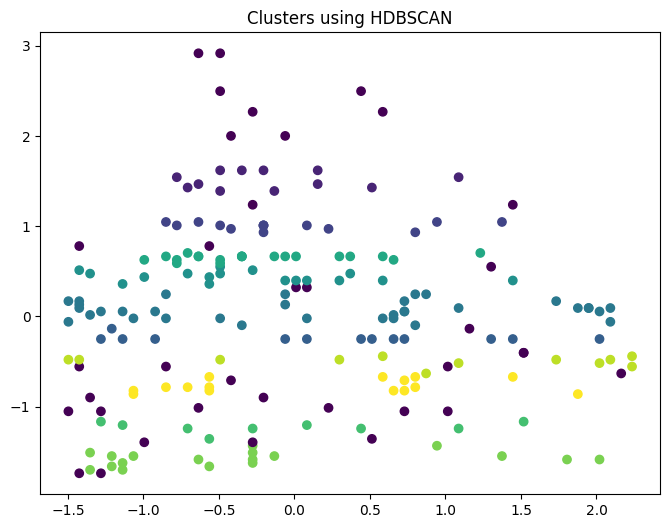

In [138]:
# Define the best model
best_model = hdbscan.HDBSCAN(cluster_selection_epsilon=0.45, min_samples=7)


# Fit the best model to your data
labels = best_model.fit_predict(df_encoded)

# Calculate evaluation metrics
silhouette = silhouette_score(df_encoded, labels)
calinski_harabasz = calinski_harabasz_score(df_encoded, labels)
davies_bouldin = davies_bouldin_score(df_encoded, labels)

# Print evaluation metrics
print(f"Algorithm: HDBSCAN")
print(f"Silhouette Coefficient: {silhouette:.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")
print()

# Create a new DataFrame with the cluster ID as the target
cluster_df = df_encoded.copy()
cluster_df['cluster_id'] = labels

# Print the new DataFrame
print(cluster_df.head())

# Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(cluster_df.iloc[:, 0], cluster_df.iloc[:, 1], c=cluster_df['cluster_id'], cmap='viridis')
plt.title("Clusters using HDBSCAN")
plt.show()


In [ ]:
labels = algorithm.fit_predict(df_encoded)
    
# Calculate evaluation metrics
if len(set(labels)) > 1:
    silhouette = silhouette_score(df_encoded, labels)
    calinski_harabasz = calinski_harabasz_score(df_encoded, labels)
    davies_bouldin = davies_bouldin_score(df_encoded, labels)
    
    # Print evaluation metrics
    print(f"Algorithm: {name}")
    print(f"Silhouette Coefficient: {silhouette:.3f}")
    print(f"Calinski-Harabasz Index: {calinski_harabasz:.3f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")
    print()

# Create a new DataFrame with the cluster ID as the target
cluster_df = df_encoded.copy()
    cluster_df['cluster_id'] = labels
    
    # Print the new DataFrame
    print(cluster_df.head())
    
    # Plot clusters
    plt.figure(figsize=(8, 6))
    plt.scatter(cluster_df.iloc[:, 0], cluster_df.iloc[:, 1], c=cluster_df['cluster_id'], cmap='viridis')
    plt.title(f"Clusters using {name}")
    plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Define clustering algorithms
algorithms = {
    'kmeans': KMeans(n_clusters=2),
    'dbscan': DBSCAN(eps=0.3, min_samples=10),
    'agg': AgglomerativeClustering(n_clusters=2),
    'gmm': GaussianMixture(n_components=2),
    'spectral': SpectralClustering(n_clusters=2),
    'hdbscan': hdbscan.HDBSCAN(min_samples=10)
}

# Evaluate clustering algorithms
for name, algorithm in algorithms.items():
    labels = algorithm.fit_predict(df_encoded)
    
    # Calculate evaluation metrics
    if len(set(labels)) > 1:
        silhouette = silhouette_score(df_encoded, labels)
        calinski_harabasz = calinski_harabasz_score(df_encoded, labels)
        davies_bouldin = davies_bouldin_score(df_encoded, labels)
        
        # Print evaluation metrics
        print(f"Algorithm: {name}")
        print(f"Silhouette Coefficient: {silhouette:.3f}")
        print(f"Calinski-Harabasz Index: {calinski_harabasz:.3f}")
        print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")
        print()
    
    # Create a new DataFrame with the cluster ID as the target
    cluster_df = df_encoded.copy()
    cluster_df['cluster_id'] = labels
    
    # Print the new DataFrame
    print(cluster_df.head())
    
    # Plot clusters
    plt.figure(figsize=(8, 6))
    plt.scatter(cluster_df.iloc[:, 0], cluster_df.iloc[:, 1], c=cluster_df['cluster_id'], cmap='viridis')
    plt.title(f"Clusters using {name}")
    plt.show()
